# SWH-TRRC-011 — Kebutuhan Air (riset)

Lanjutan dari [`note-swh-trrc.ipynb`](note-swh-trrc.ipynb) yang sudah menyelesaikan
terrain. Notebook ini menjawab satu pertanyaan: **berapa kebutuhan airnya?**

Kerangkanya penelitian, bukan perancangan bangunan. Artinya setiap angka dilacak sampai
sumbernya, setiap asumsi diberi rentang, dan ketidakpastian **ikut dilaporkan** — bukan
disembunyikan di balik satu angka tunggal.

### Sumber angka

| Apa | Dari mana | Sifat |
|---|---|---|
| Luas, lereng, elevasi | `output-swh-trrc/ringkasan_terrain.csv` | terukur (DEM) |
| Cuaca harian 2015–2024 | Open-Meteo **ERA5-Land** | reanalisis, terkoreksi elevasi |
| Cuaca pembanding | **NASA POWER** (MERRA-2) | reanalisis, grid ~50 km |
| ETo | **FAO-56 Penman-Monteith** | dihitung di notebook ini |
| ETo pembanding | Hargreaves — Arif et al. (2015) pers. (1) | `docs/admin,+14_PIJIC2015_77.pdf` |
| **Kc padi** | **Arif et al. (2015)** — diukur di **sawah terasering Indonesia** | terukur lapangan |
| Hujan andalan R80, Re, NFR, DR | KP-01 (Kriteria Perencanaan Irigasi, PUPR) | standar |
| Penyiapan lahan | Van de Goor & Zijlstra (KP-01) | standar |

### Dua hal yang harus dibaca lebih dulu

> **1. Hujan adalah suku terbesar, dan sumbernya tidak sepakat.** Di titik ini ERA5-Land
> memberi ~2.990 mm/tahun, NASA POWER ~1.730 mm/tahun — beda **73 %**. Penyebabnya
> perbedaan resolusi terhadap ketinggian: sel NASA POWER ~50 km merentang dari laut
> sampai lereng Batukaru. ERA5-Land menempatkan titik ini di **615 m**, praktis sama
> dengan DEM lahan (600–624 m). ERA5-Land dipakai sebagai acuan **karena alasan itu**,
> dan NASA POWER tetap dihitung berdampingan supaya selisihnya terlihat, bukan hilang.
>
> **2. Kc di sini bukan angka buku.** Umumnya orang memakai Kc padi FAO-56 (1,05–1,20).
> Notebook ini memakai Kc **hasil pengukuran di sawah terasering Indonesia** oleh Arif
> et al. (2015) — 1,01 / 1,02 / 1,09 / 1,05 untuk rezim genangan. Nilainya **lebih
> rendah** dari FAO-56, dan pada lahan terasering seperti SWH-TRRC-011 itu lebih layak
> dipercaya daripada angka umum.

### Yang TIDAK dihitung di sini

Ketersediaan air. Notebook ini menghitung **kebutuhan** (demand), bukan **kecukupan**
(supply vs demand) — karena debit sumber dan hak air subak belum ada datanya. Selisih
keduanya baru bisa dijawab setelah pengukuran lapangan.

## 0. Persiapan

In [1]:
import math, json, socket, urllib.request, time
from pathlib import Path
from datetime import date, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

pd.set_option("display.width", 170); pd.set_option("display.max_columns", 50)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.3, "axes.spines.top": False,
                     "axes.spines.right": False})

# ============================ KONFIGURASI ============================
TAHUN_AWAL, TAHUN_AKHIR = 2015, 2024      # rentang klimatologi
EFISIENSI_IRIGASI = 0.65                  # KP-01: 0,90 (tersier) x 0,90 (sekunder) x 0,80 (primer)
PERKOLASI_MM      = 2.0                   # mm/hari - nilai acuan; disensitivitaskan di bagian 11
PERKOLASI_UJI     = [1.0, 2.0, 3.0, 4.0]  # rentang uji
LAMA_SIAP_LAHAN   = 30                    # hari - penyiapan lahan (KP-01)
AIR_JENUH_S       = 250.0                 # mm - penjenuhan + lapisan air awal (KP-01)
WLR_MM            = 50.0                  # mm - penggantian lapisan air, 2x sepanjang musim
ALBEDO            = 0.23                  # FAO-56 untuk tanaman acuan
# =====================================================================

ROOT    = Path.cwd().parent if Path.cwd().name == "note" else Path.cwd()
DIR_TER = ROOT / "note" / "output-swh-trrc"                 # hasil notebook terrain
OUT_DIR = ROOT / "note" / "output-swh-trrc-air"; OUT_DIR.mkdir(parents=True, exist_ok=True)
GBR_DIR = OUT_DIR / "gambar";  GBR_DIR.mkdir(parents=True, exist_ok=True)
CUACA_DIR = OUT_DIR / "cuaca"; CUACA_DIR.mkdir(parents=True, exist_ok=True)

DPI_GAMBAR = 150
GAMBAR_TERSIMPAN = []
def simpan_gambar(fig, nama, dpi=None):
    b = GBR_DIR / f"{nama}.png"
    fig.savefig(b, dpi=DPI_GAMBAR if dpi is None else dpi, bbox_inches="tight",
                facecolor="white")
    GAMBAR_TERSIMPAN.append(b)
    print(f"[gambar] {b.name:<34} {b.stat().st_size/1024:>7,.0f} KB")
    return b

# ---------- ambil hasil terrain, jangan diketik ulang ----------
f_ter = DIR_TER / "ringkasan_terrain.csv"
assert f_ter.exists(), (f"Jalankan note-swh-trrc.ipynb dulu - {f_ter} belum ada.")
TER = pd.read_csv(f_ter).iloc[0]

LAT   = float(TER["lat_pusat"]);  LON = float(TER["lon_pusat"])
LUAS_HA  = float(TER["luas_datar_ha"])
LUAS_M2  = float(TER["luas_datar_m2"])
ELEVASI  = (float(TER["elev_min_m"]) + float(TER["elev_maks_m"])) / 2

print("=" * 66)
print("  WARISAN DARI ANALISIS TERRAIN")
print("=" * 66)
print(f"  Lahan          : {TER['nama_lahan']}  ({LUAS_HA:.2f} ha datar)")
print(f"  Letak          : {LAT:.5f} LS, {LON:.5f} BT")
print(f"  Elevasi        : {TER['elev_min_m']:.0f}-{TER['elev_maks_m']:.0f} m dpl "
      f"(acuan hitungan: {ELEVASI:.0f} m)")
print(f"  Lereng         : {TER['lereng_rerata_persen']:.0f} % menghadap {TER['arah_hadap']}")
print("-" * 66)
print("  CATATAN LUAS: yang dipakai adalah luas DATAR, bukan luas permukaan")
print(f"  ({TER['luas_permukaan_m2']/1e4:.2f} ha). Hujan dan ETo jatuh per satuan luas")
print("  horizontal, jadi luas proyeksi peta yang benar - bukan luas miring.")
print("=" * 66)

  WARISAN DARI ANALISIS TERRAIN
  Lahan          : SWH-TRRC-01  (3.32 ha datar)
  Letak          : -8.37121 LS, 115.13765 BT
  Elevasi        : 600-624 m dpl (acuan hitungan: 612 m)
  Lereng         : 11 % menghadap TG
------------------------------------------------------------------
  CATATAN LUAS: yang dipakai adalah luas DATAR, bukan luas permukaan
  (3.34 ha). Hujan dan ETo jatuh per satuan luas
  horizontal, jadi luas proyeksi peta yang benar - bukan luas miring.


---
## 1. Data cuaca — dua sumber, diambil apa adanya

Keduanya diunduh penuh (10 tahun harian) lalu disimpan ke `output-swh-trrc-air/cuaca/`,
sehingga notebook ini hanya perlu jaringan sekali.

Satu jebakan satuan yang harus dijinakkan di sini: **Open-Meteo mengirim kecepatan angin
dalam km/jam secara bawaan**, sedangkan FAO-56 memerlukan m/detik. Kalau tidak
dipaksa lewat parameter `wind_speed_unit=ms`, ETo akan melar ~3,6× pada suku
aerodinamis. Semua satuan karena itu ditulis eksplisit pada URL, tidak dibiarkan bawaan.

Angin juga perlu dipindah dari ketinggian 10 m ke 2 m (FAO-56 pers. 47):

$$u_2 = u_{10}\cdot\frac{4{,}87}{\ln(67{,}8\times 10 - 5{,}42)} = 0{,}748\,u_{10}$$

In [2]:
socket.setdefaulttimeout(120)
UA = {"User-Agent": "WMS-AgrinIrigation/1.0 (notebook riset lokal)"}

def unduh(url, berkas):
    """Unduh sekali, simpan mentah, pakai ulang seterusnya."""
    if berkas.exists():
        print(f"  (cache) {berkas.name}")
        return json.loads(berkas.read_text(encoding="utf-8"))
    with urllib.request.urlopen(urllib.request.Request(url, headers=UA)) as r:
        d = json.loads(r.read())
    berkas.write_text(json.dumps(d), encoding="utf-8")
    print(f"  (unduh) {berkas.name}  {berkas.stat().st_size/1024:,.0f} KB")
    return d

# ---------------- Open-Meteo ERA5-Land ----------------
u_om = ("https://archive-api.open-meteo.com/v1/archive?"
        f"latitude={LAT}&longitude={LON}"
        f"&start_date={TAHUN_AWAL}-01-01&end_date={TAHUN_AKHIR}-12-31"
        "&daily=temperature_2m_max,temperature_2m_min,precipitation_sum,"
        "et0_fao_evapotranspiration,shortwave_radiation_sum,"
        "relative_humidity_2m_mean,wind_speed_10m_mean"
        "&timezone=Asia%2FMakassar"
        "&wind_speed_unit=ms&precipitation_unit=mm&temperature_unit=celsius")
d_om = unduh(u_om, CUACA_DIR / "open_meteo_era5land.json")
dd = d_om["daily"]
era = pd.DataFrame({
    "tanggal": pd.to_datetime(dd["time"]),
    "tmaks":   dd["temperature_2m_max"],
    "tmin":    dd["temperature_2m_min"],
    "hujan":   dd["precipitation_sum"],
    "rs":      dd["shortwave_radiation_sum"],      # MJ/m2/hari
    "rh":      dd["relative_humidity_2m_mean"],    # %
    "u10":     dd["wind_speed_10m_mean"],          # m/s (dipaksa)
    "eto_om":  dd["et0_fao_evapotranspiration"],   # ETo versi Open-Meteo
})
ELEV_MODEL_OM = d_om.get("elevation")

# ---------------- NASA POWER ----------------
u_np = ("https://power.larc.nasa.gov/api/temporal/daily/point?"
        "parameters=T2M_MAX,T2M_MIN,RH2M,WS2M,ALLSKY_SFC_SW_DWN,PRECTOTCORR"
        f"&community=AG&longitude={LON}&latitude={LAT}"
        f"&start={TAHUN_AWAL}0101&end={TAHUN_AKHIR}1231&format=JSON")
d_np = unduh(u_np, CUACA_DIR / "nasa_power.json")
pp = d_np["properties"]["parameter"]
pw = pd.DataFrame({
    "tanggal": pd.to_datetime(list(pp["T2M_MAX"]), format="%Y%m%d"),
    "tmaks":   list(pp["T2M_MAX"].values()),
    "tmin":    list(pp["T2M_MIN"].values()),
    "rh":      list(pp["RH2M"].values()),
    "u2":      list(pp["WS2M"].values()),          # sudah 2 m
    "rs":      list(pp["ALLSKY_SFC_SW_DWN"].values()),
    "hujan":   list(pp["PRECTOTCORR"].values()),
}).replace(-999.0, np.nan)

# ---------------- penyeragaman ----------------
era["u2"] = era["u10"] * 0.748          # FAO-56 pers. (47): 10 m -> 2 m
for df in (era, pw):
    df["tahun"]  = df["tanggal"].dt.year
    df["bulan"]  = df["tanggal"].dt.month
    df["doy"]    = df["tanggal"].dt.dayofyear
    df["tmean"]  = (df["tmaks"] + df["tmin"]) / 2
    # periode setengah-bulanan KP-01: 1..24
    df["periode"] = (df["bulan"] - 1)*2 + np.where(df["tanggal"].dt.day <= 15, 1, 2)

print(f"\nERA5-Land : {len(era):,} hari | elevasi model {ELEV_MODEL_OM} m "
      f"(DEM lahan {TER['elev_min_m']:.0f}-{TER['elev_maks_m']:.0f} m)")
print(f"NASA POWER: {len(pw):,} hari | grid ~50 km, tanpa koreksi elevasi")
print(f"\nCek satuan angin (kalau salah, ETo akan melar ~3,6x):")
print(f"  ERA5 u10 {era['u10'].mean():.2f} m/s -> u2 {era['u2'].mean():.2f} m/s")
print(f"  POWER u2 {pw['u2'].mean():.2f} m/s")
print(f"  -> selisih {abs(era['u2'].mean()-pw['u2'].mean()):.2f} m/s: "
      f"{'WAJAR, satuan benar' if abs(era['u2'].mean()-pw['u2'].mean()) < 0.5 else 'PERIKSA SATUAN'}")

  (cache) open_meteo_era5land.json
  (cache) nasa_power.json

ERA5-Land : 3,653 hari | elevasi model 615.0 m (DEM lahan 600-624 m)
NASA POWER: 3,653 hari | grid ~50 km, tanpa koreksi elevasi

Cek satuan angin (kalau salah, ETo akan melar ~3,6x):
  ERA5 u10 1.80 m/s -> u2 1.35 m/s
  POWER u2 1.35 m/s
  -> selisih 0.00 m/s: WAJAR, satuan benar


### 1b. Seberapa jauh kedua sumber berbeda?

Yang dibandingkan bukan cuma rata-ratanya, tapi **variabel mana** yang berbeda. Itu yang
menunjukkan penyebabnya. Kalau yang berbeda hanya hujan dan suhu (variabel yang
dikendalikan ketinggian) sedangkan angin sepakat (variabel skala besar), maka
penyebabnya resolusi terhadap topografi — bukan kesalahan salah satu sumber.

            PERBANDINGAN DUA SUMBER (rata-rata 10 tahun)
  variabel                      ERA5-Land   NASA POWER      selisih
--------------------------------------------------------------------------
  Hujan tahunan (mm)              2,989.4      1,727.5        73.1 %
  Suhu maks (C)                      25.9         28.4        -8.9 %
  Suhu min (C)                       20.5         23.5       -12.4 %
  Radiasi (MJ/m2/hr)                 18.3         20.1        -8.8 %
  Kelembapan (%)                     88.8         83.6         6.1 %
  Angin 2 m (m/s)                     1.3          1.4        -0.3 %
  Angin sepakat (0.00 m/s beda) -> keduanya membaca sirkulasi yang sama.
  Hujan & suhu berbeda jauh -> yang membedakan adalah KETINGGIAN.
  ERA5-Land menaruh titik ini di 615 m; lahan sesungguhnya 600-624 m.


[gambar] 01_dua_sumber_cuaca.png                120 KB


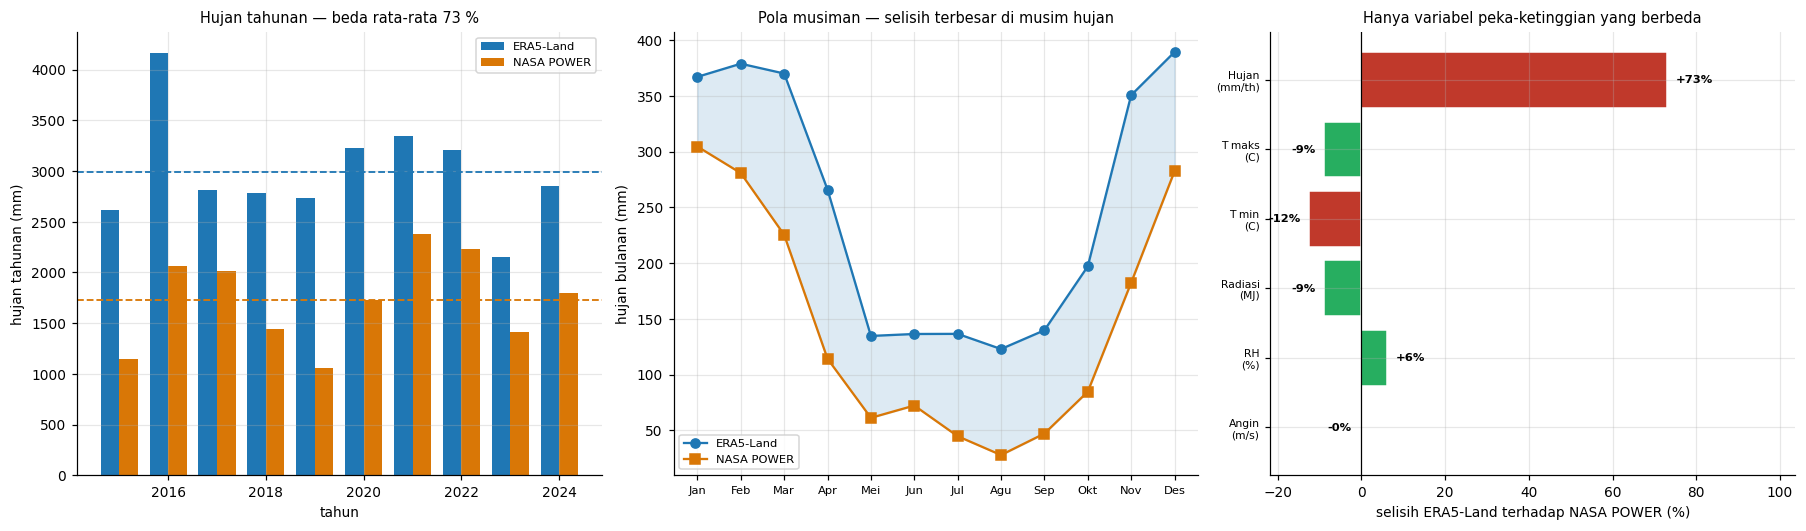

In [3]:
def ringkas_tahunan(df, nama):
    g = df.groupby("tahun").agg(hujan=("hujan", "sum"), tmaks=("tmaks", "mean"),
                                tmin=("tmin", "mean"), rs=("rs", "mean"),
                                rh=("rh", "mean"), u2=("u2", "mean"))
    g["sumber"] = nama
    return g

th_era, th_pw = ringkas_tahunan(era, "ERA5-Land"), ringkas_tahunan(pw, "NASA POWER")

print("=" * 74)
print("            PERBANDINGAN DUA SUMBER (rata-rata 10 tahun)")
print("=" * 74)
print(f"  {'variabel':<26}{'ERA5-Land':>13}{'NASA POWER':>13}{'selisih':>13}")
print("-" * 74)
baris = [("Hujan tahunan (mm)",  th_era['hujan'].mean(), th_pw['hujan'].mean()),
         ("Suhu maks (C)",       th_era['tmaks'].mean(), th_pw['tmaks'].mean()),
         ("Suhu min (C)",        th_era['tmin'].mean(),  th_pw['tmin'].mean()),
         ("Radiasi (MJ/m2/hr)",  th_era['rs'].mean(),    th_pw['rs'].mean()),
         ("Kelembapan (%)",      th_era['rh'].mean(),    th_pw['rh'].mean()),
         ("Angin 2 m (m/s)",     th_era['u2'].mean(),    th_pw['u2'].mean())]
for n, a, b in baris:
    bd = 100*(a-b)/b if b else np.nan
    print(f"  {n:<26}{a:>13,.1f}{b:>13,.1f}{bd:>12,.1f} %")
print("=" * 74)
print(f"  Angin sepakat ({abs(th_era['u2'].mean()-th_pw['u2'].mean()):.2f} m/s beda) "
      f"-> keduanya membaca sirkulasi yang sama.")
print(f"  Hujan & suhu berbeda jauh -> yang membedakan adalah KETINGGIAN.")
print(f"  ERA5-Land menaruh titik ini di {ELEV_MODEL_OM:.0f} m; lahan sesungguhnya "
      f"{TER['elev_min_m']:.0f}-{TER['elev_maks_m']:.0f} m.")
print("=" * 74)

# ---------------- gambar ----------------
fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.9))

ax = axes[0]
w = 0.38; xs = np.arange(TAHUN_AWAL, TAHUN_AKHIR+1)
ax.bar(xs-w/2, th_era["hujan"], w, label="ERA5-Land", color="#1f77b4")
ax.bar(xs+w/2, th_pw["hujan"],  w, label="NASA POWER", color="#d97706")
ax.axhline(th_era["hujan"].mean(), color="#1f77b4", ls="--", lw=1.2)
ax.axhline(th_pw["hujan"].mean(),  color="#d97706", ls="--", lw=1.2)
ax.set_ylabel("hujan tahunan (mm)"); ax.set_xlabel("tahun")
ax.set_title(f"Hujan tahunan — beda rata-rata "
             f"{100*(th_era['hujan'].mean()-th_pw['hujan'].mean())/th_pw['hujan'].mean():.0f} %",
             fontsize=9.5)
ax.legend(fontsize=7.5); ax.set_aspect("auto")

ax = axes[1]
bl_e = era.groupby("bulan")["hujan"].sum()/ (TAHUN_AKHIR-TAHUN_AWAL+1)
bl_p = pw.groupby("bulan")["hujan"].sum() / (TAHUN_AKHIR-TAHUN_AWAL+1)
NB = ["Jan","Feb","Mar","Apr","Mei","Jun","Jul","Agu","Sep","Okt","Nov","Des"]
ax.plot(range(1,13), bl_e, "o-", color="#1f77b4", label="ERA5-Land")
ax.plot(range(1,13), bl_p, "s-", color="#d97706", label="NASA POWER")
ax.fill_between(range(1,13), bl_p, bl_e, alpha=0.15, color="#1f77b4")
ax.set_xticks(range(1,13)); ax.set_xticklabels(NB, fontsize=7.5)
ax.set_ylabel("hujan bulanan (mm)")
ax.set_title("Pola musiman — selisih terbesar di musim hujan", fontsize=9.5)
ax.legend(fontsize=7.5); ax.set_aspect("auto")

ax = axes[2]
kat = ["Hujan\n(mm/th)", "T maks\n(C)", "T min\n(C)", "Radiasi\n(MJ)", "RH\n(%)", "Angin\n(m/s)"]
beda = [100*(a-b)/b for _, a, b in baris]
warna = ["#c0392b" if abs(v) > 10 else "#27ae60" for v in beda]
ax.barh(range(6), beda, color=warna, edgecolor="white")
ax.axvline(0, color="black", lw=0.8)
ax.set_yticks(range(6)); ax.set_yticklabels(kat, fontsize=7)
ax.invert_yaxis(); ax.set_xlabel("selisih ERA5-Land terhadap NASA POWER (%)")
ax.set_title("Hanya variabel peka-ketinggian yang berbeda", fontsize=9.5)
for i, v in enumerate(beda):
    ax.text(v + (2 if v >= 0 else -2), i, f"{v:+.0f}%", va="center",
            ha="left" if v >= 0 else "right", fontsize=7.5, weight="bold")
ax.set_aspect("auto"); ax.set_xlim(min(beda)*1.35-5, max(beda)*1.35+5)

plt.tight_layout()
simpan_gambar(fig, "01_dua_sumber_cuaca"); plt.show()

---
## 2. Evapotranspirasi acuan (ETo)

**FAO-56 Penman-Monteith** dipakai sebagai acuan karena semua variabelnya tersedia
(suhu, kelembapan, angin, radiasi) — ini standar internasional:

$$ET_o=\frac{0{,}408\,\Delta\,(R_n-G)+\gamma\frac{900}{T+273}u_2(e_s-e_a)}{\Delta+\gamma(1+0{,}34\,u_2)}$$

Dihitung dari nol di notebook ini supaya bisa diperiksa, **bukan** diambil jadi dari API.

Dua pembanding dipakai untuk menguji hasilnya:

1. **Hargreaves — Arif et al. (2015) pers. (1)**, persamaan yang dipakai referensi repo ini:
   $$ET_o = 0{,}0135\,(T_{mean}+17{,}78)\,R_s\left(\frac{238{,}8}{595{,}5-0{,}55\,T_{mean}}\right)$$
2. **ETo bawaan Open-Meteo** — perhitungan pihak ketiga yang sepenuhnya independen.

Kalau ketiganya berdekatan, ETo boleh dipercaya. Kalau berjauhan, ada yang salah —
dan lebih baik ketahuan di sini daripada terbawa sampai angka debit.

                  EVAPOTRANSPIRASI ACUAN (ETo)
  metode                                mm/hari    mm/tahun
--------------------------------------------------------------------------
  FAO-56 Penman-Monteith (ERA5)            3.41       1,246   <- DIPAKAI
  Hargreaves/Arif 2015 (ERA5)              4.17       1,521
  ETo bawaan Open-Meteo                    3.40       1,241
  FAO-56 Penman-Monteith (POWER)           4.06       1,480
--------------------------------------------------------------------------
  Open-Meteo terhadap PM : -0.4 %   <- UJI IMPLEMENTASI
  Hargreaves terhadap PM : +22.1 %   <- BEDA METODE, bukan galat
--------------------------------------------------------------------------
  ETo Penman-Monteith TERVALIDASI: hasil di sini cocok dengan hitungan
  independen Open-Meteo dalam 0.4 % -> rumusnya ditulis benar.

  Hargreaves +22 % adalah perilaku yang MEMANG DIHARAPKAN di sini:
  rumus itu hanya memakai suhu dan radiasi, tidak melihat kelembapan,
  padahal RH di lokasi

[gambar] 02_eto.png                             229 KB


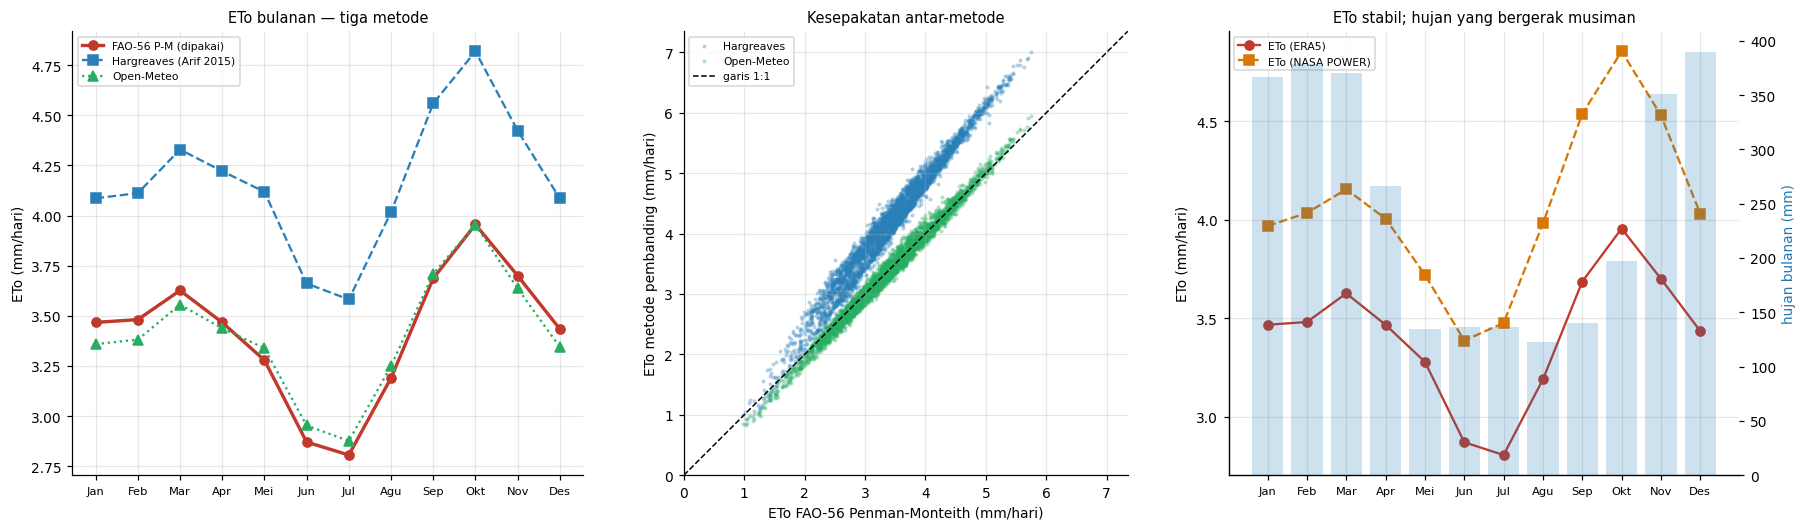

In [4]:
def radiasi_ekstra(doy, lat_deg):
    """Ra - radiasi ekstraterestrial (MJ m-2 hari-1). FAO-56 pers. (21)."""
    phi = math.radians(lat_deg)
    dr  = 1 + 0.033*np.cos(2*np.pi*doy/365)
    dec = 0.409*np.sin(2*np.pi*doy/365 - 1.39)
    ws  = np.arccos(np.clip(-np.tan(phi)*np.tan(dec), -1, 1))
    return (24*60/np.pi)*0.0820*dr*(ws*np.sin(phi)*np.sin(dec) +
                                    np.cos(phi)*np.cos(dec)*np.sin(ws))

def eto_penman_monteith(tmaks, tmin, rh, u2, rs, doy, lat_deg, z):
    """ETo harian (mm/hari) menurut FAO-56 pers. (6)."""
    tmean = (tmaks + tmin)/2
    P     = 101.3*((293 - 0.0065*z)/293)**5.26          # tekanan udara (kPa)
    gamma = 0.000665*P                                   # konstanta psikrometrik
    delta = (4098*(0.6108*np.exp(17.27*tmean/(tmean+237.3)))/(tmean+237.3)**2)
    e_maks = 0.6108*np.exp(17.27*tmaks/(tmaks+237.3))
    e_min  = 0.6108*np.exp(17.27*tmin /(tmin +237.3))
    es = (e_maks + e_min)/2
    ea = es*rh/100
    Ra  = radiasi_ekstra(doy, lat_deg)
    Rso = (0.75 + 2e-5*z)*Ra                             # radiasi langit cerah
    Rns = (1 - ALBEDO)*rs
    Rnl = (4.903e-9*(((tmaks+273.16)**4 + (tmin+273.16)**4)/2) *
           (0.34 - 0.14*np.sqrt(np.maximum(ea, 0))) *
           (1.35*np.clip(rs/Rso, 0, 1) - 0.35))
    Rn = Rns - Rnl                                       # G diabaikan (harian)
    eto = ((0.408*delta*Rn + gamma*(900/(tmean+273))*u2*(es-ea)) /
           (delta + gamma*(1 + 0.34*u2)))
    return np.maximum(eto, 0)

def eto_hargreaves_arif(tmean, rs):
    """Arif et al. (2015) pers. (1) - Rs dalam MJ/m2/hari."""
    return 0.0135*(tmean + 17.78)*rs*(238.8/(595.5 - 0.55*tmean))

for df in (era, pw):
    df["eto_pm"] = eto_penman_monteith(df["tmaks"], df["tmin"], df["rh"], df["u2"],
                                       df["rs"], df["doy"], LAT, ELEVASI)
    df["eto_hg"] = eto_hargreaves_arif(df["tmean"], df["rs"])

ETO_HARIAN = float(era["eto_pm"].mean())
print("=" * 74)
print("                  EVAPOTRANSPIRASI ACUAN (ETo)")
print("=" * 74)
print(f"  {'metode':<34}{'mm/hari':>11}{'mm/tahun':>12}")
print("-" * 74)
print(f"  {'FAO-56 Penman-Monteith (ERA5)':<34}{era['eto_pm'].mean():>11.2f}"
      f"{era['eto_pm'].mean()*365:>12,.0f}   <- DIPAKAI")
print(f"  {'Hargreaves/Arif 2015 (ERA5)':<34}{era['eto_hg'].mean():>11.2f}"
      f"{era['eto_hg'].mean()*365:>12,.0f}")
print(f"  {'ETo bawaan Open-Meteo':<34}{era['eto_om'].mean():>11.2f}"
      f"{era['eto_om'].mean()*365:>12,.0f}")
print(f"  {'FAO-56 Penman-Monteith (POWER)':<34}{pw['eto_pm'].mean():>11.2f}"
      f"{pw['eto_pm'].mean()*365:>12,.0f}")
print("-" * 74)
sel_hg = 100*(era['eto_hg'].mean()-era['eto_pm'].mean())/era['eto_pm'].mean()
sel_om = 100*(era['eto_om'].mean()-era['eto_pm'].mean())/era['eto_pm'].mean()
print(f"  Open-Meteo terhadap PM : {sel_om:+.1f} %   <- UJI IMPLEMENTASI")
print(f"  Hargreaves terhadap PM : {sel_hg:+.1f} %   <- BEDA METODE, bukan galat")
print("-" * 74)
# Dua pembanding ini menguji hal yang BERBEDA dan tidak boleh dijadikan satu angka.
# Open-Meteo memakai rumus yang sama (FAO-56) pada data yang sama -> kalau cocok,
# berarti rumus di notebook ini ditulis benar. Hargreaves rumus yang lain sama sekali.
if abs(sel_om) < 5:
    print(f"  ETo Penman-Monteith TERVALIDASI: hasil di sini cocok dengan hitungan")
    print(f"  independen Open-Meteo dalam {abs(sel_om):.1f} % -> rumusnya ditulis benar.")
else:
    print(f"  PERIKSA: selisih {abs(sel_om):.1f} % terhadap hitungan FAO-56 independen")
    print( "  terlalu besar untuk rumus yang sama - kemungkinan ada masukan yang salah.")
print(f"\n  Hargreaves {sel_hg:+.0f} % adalah perilaku yang MEMANG DIHARAPKAN di sini:")
print(f"  rumus itu hanya memakai suhu dan radiasi, tidak melihat kelembapan,")
print(f"  padahal RH di lokasi ini {era['rh'].mean():.0f} %. Udara yang sudah hampir jenuh")
print(f"  menekan penguapan, dan Hargreaves tidak dapat melihatnya -> ETo melebih.")
print(f"  -> Penman-Monteith dipakai. Hargreaves dicatat sebagai BATAS ATAS.")
print("=" * 74)
print(f"  Pembanding lapangan: Arif et al. (2015) mengukur ETo 3,5-6,0 mm/hari")
print(f"  di sawah terasering Jawa Tengah (musim kemarau). Hasil di sini "
      f"{era['eto_pm'].min():.1f}-{era['eto_pm'].max():.1f} mm/hari.")
print("=" * 74)

fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.9))

ax = axes[0]
bl = era.groupby("bulan")[["eto_pm", "eto_hg", "eto_om"]].mean()
ax.plot(range(1,13), bl["eto_pm"], "o-", lw=2.2, color="#c0392b", label="FAO-56 P-M (dipakai)")
ax.plot(range(1,13), bl["eto_hg"], "s--", color="#2980b9", label="Hargreaves (Arif 2015)")
ax.plot(range(1,13), bl["eto_om"], "^:", color="#27ae60", label="Open-Meteo")
ax.set_xticks(range(1,13)); ax.set_xticklabels(NB, fontsize=7.5)
ax.set_ylabel("ETo (mm/hari)"); ax.set_title("ETo bulanan — tiga metode", fontsize=9.5)
ax.legend(fontsize=7); ax.set_aspect("auto")

ax = axes[1]
ax.scatter(era["eto_pm"], era["eto_hg"], s=3, alpha=0.25, color="#2980b9",
           label="Hargreaves")
ax.scatter(era["eto_pm"], era["eto_om"], s=3, alpha=0.25, color="#27ae60",
           label="Open-Meteo")
lim = [0, max(era["eto_pm"].max(), era["eto_hg"].max())*1.05]
ax.plot(lim, lim, "k--", lw=1, label="garis 1:1")
ax.set_xlabel("ETo FAO-56 Penman-Monteith (mm/hari)")
ax.set_ylabel("ETo metode pembanding (mm/hari)")
ax.set_title("Kesepakatan antar-metode", fontsize=9.5)
ax.legend(fontsize=7); ax.set_aspect("equal"); ax.set_xlim(lim); ax.set_ylim(lim)

ax = axes[2]
ax.plot(range(1,13), era.groupby("bulan")["eto_pm"].mean(), "o-", color="#c0392b",
        label="ETo (ERA5)")
ax.plot(range(1,13), pw.groupby("bulan")["eto_pm"].mean(), "s--", color="#d97706",
        label="ETo (NASA POWER)")
ax2 = ax.twinx()
ax2.bar(range(1,13), bl_e, alpha=0.22, color="#1f77b4", label="hujan (ERA5)")
ax2.set_ylabel("hujan bulanan (mm)", color="#1f77b4")
ax2.grid(False)
ax.set_xticks(range(1,13)); ax.set_xticklabels(NB, fontsize=7.5)
ax.set_ylabel("ETo (mm/hari)")
ax.set_title("ETo stabil; hujan yang bergerak musiman", fontsize=9.5)
ax.legend(fontsize=7, loc="upper left"); ax.set_aspect("auto")

plt.tight_layout()
simpan_gambar(fig, "02_eto"); plt.show()

---
## 3. Hujan andalan (R80) dan hujan efektif

Untuk perencanaan irigasi, **hujan rata-rata tidak boleh dipakai** — separuh tahun akan
lebih kering dari itu dan jaringan gagal separuh waktu. KP-01 memakai **hujan andalan
R80**: besaran hujan yang **terlampaui pada 8 dari 10 tahun**. Artinya rancangan aman
pada 80 % tahun.

Hitungannya per **periode setengah-bulanan** (24 periode/tahun, sesuai KP-01), bukan
per bulan — supaya jeda kering di tengah bulan tidak tertutup rata-rata.

Hujan efektif untuk padi (KP-01):

$$R_e = \frac{0{,}7 \times R_{80}}{\text{jumlah hari periode}}$$

Faktor 0,7 mengakui bahwa **tidak semua hujan berguna**: sebagian melimpas lewat lubang
buang, sebagian jatuh saat petak sudah penuh. Pada lahan berlereng 11 % seperti ini,
faktor itu boleh jadi masih terlalu murah hati — dibahas di bagian batasan.

        HUJAN ANDALAN R80 DAN HUJAN EFEKTIF (per setengah bulan)
  periode       rata2      R50      R80       Re               
                 (mm)     (mm)     (mm)  (mm/hr)
------------------------------------------------------------------------------
  Jan-I           177      143      103     4.81   ########
  Jan-II          190      189      121     5.31   ##########
  Feb-I           216      197      160     7.47   #############
  Feb-II          163      143      132     6.93   ##########
  Mar-I           203      167      130     6.07   ##########
  Mar-II          167      156      107     4.70   ########
  Apr-I           142      138       68     3.18   #####
  Apr-II          123      120       64     2.99   #####
  Mei-I            53       53       35     1.64   ##
  Mei-II           82       62       36     1.59   ###
  Jun-I            65       52       38     1.78   ###
  Jun-II           71       62       25     1.15   ##
  Jul-I            76       67       55 

[gambar] 03_hujan_andalan.png                   144 KB


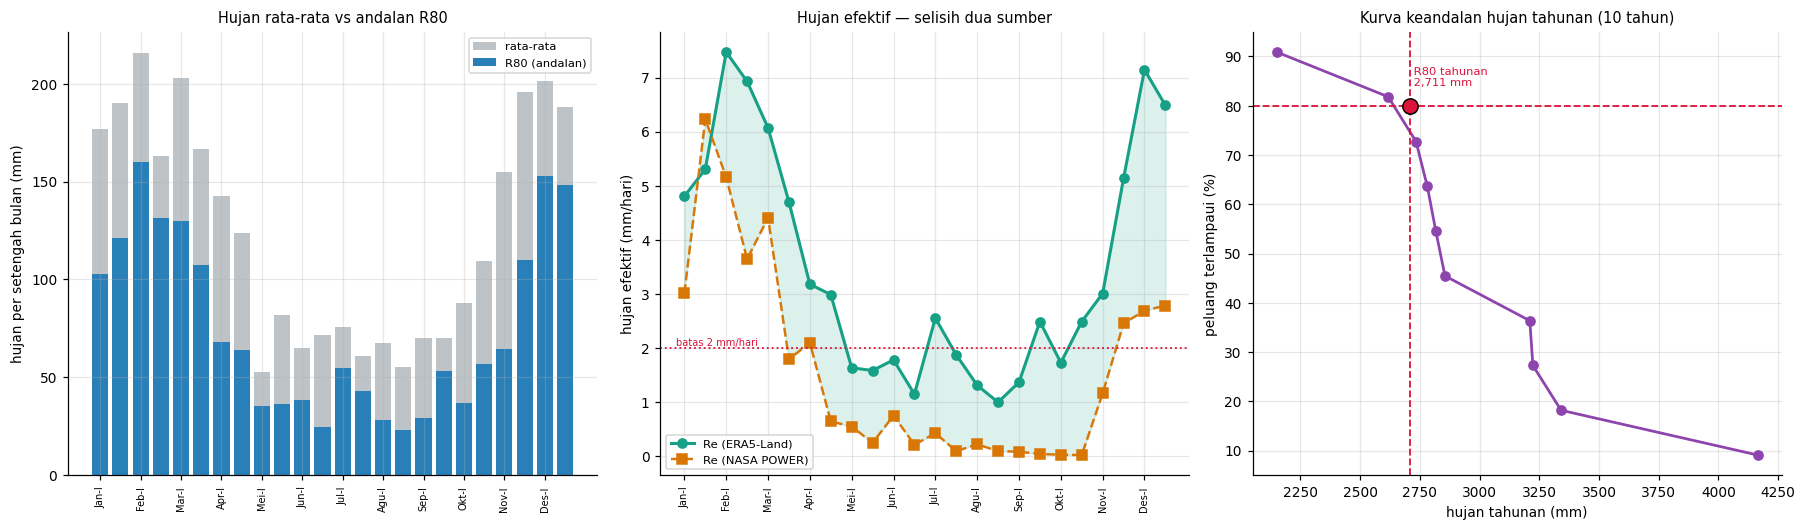

In [5]:
HARI_PERIODE = era.groupby(["tahun", "periode"]).size().groupby("periode").mean()

def hujan_andalan(df, keandalan=80):
    """R80 per periode setengah-bulanan: hujan yang terlampaui pada 80 % tahun."""
    tot = df.groupby(["tahun", "periode"])["hujan"].sum().reset_index()
    # terlampaui 80 % tahun == persentil ke-20 dari sebaran antar-tahun
    return tot.groupby("periode")["hujan"].quantile(1 - keandalan/100)

R80  = hujan_andalan(era)
R50  = hujan_andalan(era, 50)
RRAT = era.groupby(["tahun","periode"])["hujan"].sum().groupby("periode").mean()
R80_PW = hujan_andalan(pw)

RE = 0.7 * R80 / HARI_PERIODE          # mm/hari
RE_PW = 0.7 * R80_PW / HARI_PERIODE

def label_periode(p):
    return f"{NB[(p-1)//2]}-{'I' if p % 2 else 'II'}"
LBL = [label_periode(p) for p in range(1, 25)]

print("=" * 78)
print("        HUJAN ANDALAN R80 DAN HUJAN EFEKTIF (per setengah bulan)")
print("=" * 78)
print(f"  {'periode':<10}{'rata2':>9}{'R50':>9}{'R80':>9}{'Re':>9}   {'':<12}")
print(f"  {'':<10}{'(mm)':>9}{'(mm)':>9}{'(mm)':>9}{'(mm/hr)':>9}")
print("-" * 78)
for p in range(1, 25):
    bar = "#" * int(R80[p]/12)
    print(f"  {LBL[p-1]:<10}{RRAT[p]:>9.0f}{R50[p]:>9.0f}{R80[p]:>9.0f}"
          f"{RE[p]:>9.2f}   {bar}")
print("-" * 78)
print(f"  Hujan tahunan rata-rata : {RRAT.sum():>7,.0f} mm")
print(f"  Hujan tahunan andalan   : {R80.sum():>7,.0f} mm  "
      f"({100*R80.sum()/RRAT.sum():.0f} % dari rata-rata)")
print(f"  Hujan efektif tahunan   : {(RE*HARI_PERIODE).sum():>7,.0f} mm")
print("-" * 78)
kering = [LBL[p-1] for p in range(1,25) if RE[p] < 2.0]
print(f"  Periode dengan Re < 2 mm/hari ({len(kering)} dari 24): "
      f"{', '.join(kering) if kering else 'tidak ada'}")
print("=" * 78)

fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.9))

ax = axes[0]
xs = np.arange(1, 25)
ax.bar(xs, RRAT.values, color="#bdc3c7", label="rata-rata")
ax.bar(xs, R80.values, color="#2980b9", label="R80 (andalan)")
ax.set_xticks(xs[::2]); ax.set_xticklabels(LBL[::2], rotation=90, fontsize=6.5)
ax.set_ylabel("hujan per setengah bulan (mm)")
ax.set_title("Hujan rata-rata vs andalan R80", fontsize=9.5)
ax.legend(fontsize=7.5); ax.set_aspect("auto")

ax = axes[1]
ax.plot(xs, RE.values, "o-", color="#16a085", lw=2, label="Re (ERA5-Land)")
ax.plot(xs, RE_PW.values, "s--", color="#d97706", lw=1.6, label="Re (NASA POWER)")
ax.axhline(2.0, color="crimson", ls=":", lw=1.2)
ax.text(0.6, 2.05, "batas 2 mm/hari", fontsize=6.5, color="crimson")
ax.fill_between(xs, RE_PW.values, RE.values, alpha=0.15, color="#16a085")
ax.set_xticks(xs[::2]); ax.set_xticklabels(LBL[::2], rotation=90, fontsize=6.5)
ax.set_ylabel("hujan efektif (mm/hari)")
ax.set_title("Hujan efektif — selisih dua sumber", fontsize=9.5)
ax.legend(fontsize=7.5); ax.set_aspect("auto")

ax = axes[2]
tot_th = era.groupby("tahun")["hujan"].sum().sort_values()
n = len(tot_th)
prob = np.arange(1, n+1)/(n+1)*100
ax.plot(tot_th.values, 100-prob, "o-", color="#8e44ad", lw=1.8)
ax.axhline(80, color="crimson", ls="--", lw=1.2)
r80_th = np.quantile(tot_th.values, 0.2)
ax.axvline(r80_th, color="crimson", ls="--", lw=1.2)
ax.plot([r80_th], [80], "o", ms=10, mfc="crimson", mec="black", zorder=5)
ax.text(r80_th, 84, f" R80 tahunan\n {r80_th:,.0f} mm", fontsize=7.5, color="crimson")
ax.set_xlabel("hujan tahunan (mm)"); ax.set_ylabel("peluang terlampaui (%)")
ax.set_title(f"Kurva keandalan hujan tahunan ({n} tahun)", fontsize=9.5)
ax.set_aspect("auto")

plt.tight_layout()
simpan_gambar(fig, "03_hujan_andalan"); plt.show()

---
## 4. Koefisien tanaman (Kc) dan dua kalender tanam

Di sinilah notebook ini menyimpang dari kebiasaan. Umumnya Kc padi diambil dari FAO-56
(1,05 awal / 1,20 tengah / 0,90 akhir). Yang dipakai di sini adalah **Kc hasil pengukuran
langsung di sawah terasering Indonesia** — Arif et al. (2015), Wonogiri, Jawa Tengah:

| Tahap | Kc genangan (FL) | Kc SRI (intermiten) |
|---|---|---|
| Awal (*initial*) | 1,01 | 1,00 |
| Perkembangan (*crop development*) | 1,02 | 0,96 |
| Reproduktif (*mid-season*) | **1,09** | 1,02 |
| Akhir (*late*) | 1,05 | 1,04 |

Nilainya **lebih rendah** dari FAO-56, dan itu masuk akal untuk lahan terasering.
Memakai FAO-56 di sini akan **melebih-lebihkan** kebutuhan air sekitar 10 %.

Dua rezim air sekaligus dihitung, karena bedanya justru inti penelitian: pada percobaan
itu SRI memakai air lebih sedikit **tetapi hasil gabahnya lebih tinggi**
(8,05 vs 7,63 ton/ha).

> **SRI tidak cukup diwakili oleh Kc saja.** Selisih Kc antara kedua rezim hanya ~4 %,
> padahal Arif et al. melaporkan penghematan air **26 %**. Sebabnya: penghematan SRI
> datang dari petak yang **tidak digenangi terus-menerus**, bukan dari tanamannya
> menguapkan lebih sedikit. Maka rezim SRI di sini juga memakai **perkolasi 0,60×**
> (petak tak tergenang meresap lebih sedikit) dan **tanpa penggantian lapisan air**
> (tidak ada lapisan tetap untuk diganti). Kalau hanya Kc yang diubah, kesimpulan
> "SRI hampir tidak menghemat" akan keliru — dan itu kekeliruan model, bukan temuan.

Dua kalender tanam sesuai permintaan: **110 hari** (varietas modern) dan **150 hari**
(padi lokal umur panjang).

           KOEFISIEN TANAMAN DAN KALENDER TANAM

  110 hari (modern)  (total 110 hari + 30 hari siap lahan)
    tahap              hari    Kc FL   Kc SRI  Kc FAO-56
    awal                 20     1.01     1.00       1.05
    perkembangan         30     1.02     0.96       1.10
    reproduktif          40     1.09     1.02       1.20
    akhir                20     1.05     1.04       0.90
    Kc rata-rata tertimbang FL  (genangan)    : 1.049
    Kc rata-rata tertimbang SRI (intermiten)  : 1.004
    Kc rata-rata tertimbang FAO-56 (pembanding): 1.091

  150 hari (lokal)  (total 150 hari + 30 hari siap lahan)
    tahap              hari    Kc FL   Kc SRI  Kc FAO-56
    awal                 30     1.01     1.00       1.05
    perkembangan         40     1.02     0.96       1.10
    reproduktif          50     1.09     1.02       1.20
    akhir                30     1.05     1.04       0.90
    Kc rata-rata tertimbang FL  (genangan)    : 1.047
    Kc rata-rata tertimbang SRI (intermiten)  

[gambar] 04_kc_kalender.png                      65 KB


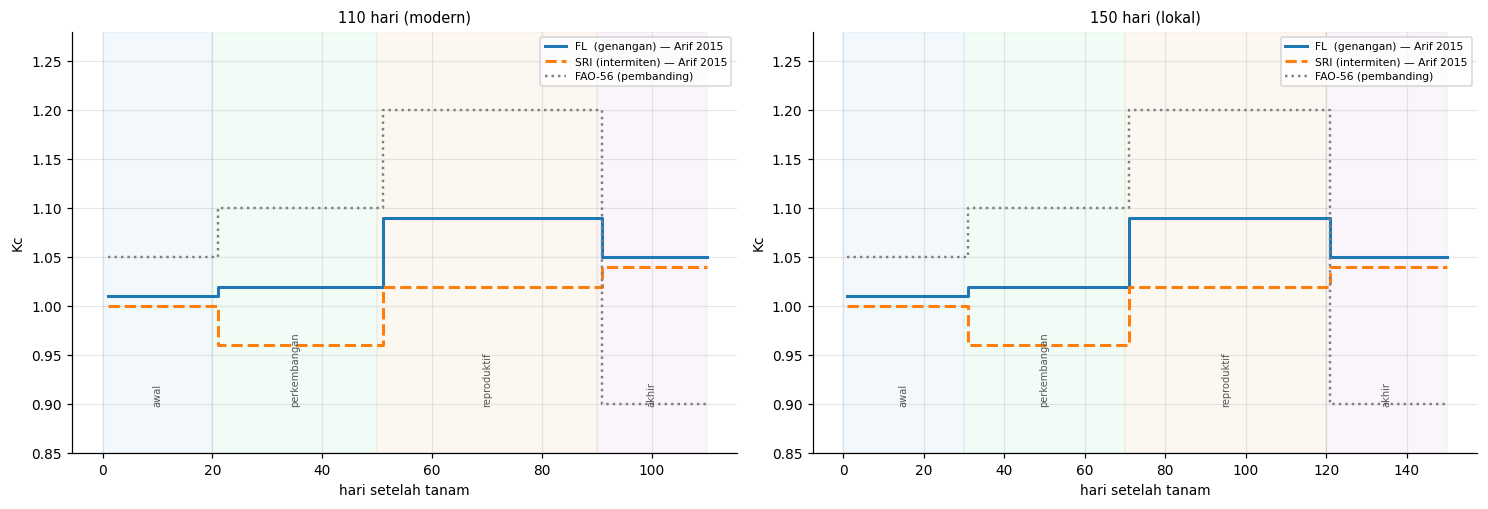

In [6]:
# Kc terukur - Arif et al. (2015), sawah terasering Indonesia
KC = {
    "FL  (genangan)":  [1.01, 1.02, 1.09, 1.05],
    "SRI (intermiten)":[1.00, 0.96, 1.02, 1.04],
}
KC_FAO = [1.05, 1.10, 1.20, 0.90]      # FAO-56 - hanya untuk pembanding

# Perbedaan SRI TIDAK terletak pada Kc saja. Kc hanya mengatur penguapan tanaman,
# padahal penghematan SRI justru datang dari petak yang TIDAK digenangi terus:
#   - tanpa genangan tetap -> perkolasi turun (dipakai 0,60x, sama seperti note-swh.ipynb)
#   - tanpa lapisan air tetap -> tidak ada penggantian lapisan air (WLR = 0)
# Kalau hanya Kc yang diturunkan, SRI hanya tampak hemat ~3 % - jauh di bawah
# 26 % yang dilaporkan Arif et al. (2015) untuk Indonesia. Selisih itu bukan
# ketidakcocokan data, melainkan tanda modelnya belum lengkap.
REZIM = {
    "FL  (genangan)":   {"perk_faktor": 1.00, "wlr": WLR_MM},
    "SRI (intermiten)": {"perk_faktor": 0.60, "wlr": 0.0},
}

# pembagian tahap: awal, perkembangan, reproduktif, akhir
KALENDER = {
    "110 hari (modern)": [20, 30, 40, 20],
    "150 hari (lokal)":  [30, 40, 50, 30],
}
NAMA_TAHAP = ["awal", "perkembangan", "reproduktif", "akhir"]

def deret_kc(tahap_hari, kc_nilai):
    """Kc harian sepanjang musim (fungsi tangga: paper melaporkan rata-rata per tahap)."""
    out = []
    for lama, k in zip(tahap_hari, kc_nilai):
        out += [k]*lama
    return np.array(out)

print("=" * 76)
print("           KOEFISIEN TANAMAN DAN KALENDER TANAM")
print("=" * 76)
for nk, tahap in KALENDER.items():
    print(f"\n  {nk}  (total {sum(tahap)} hari + {LAMA_SIAP_LAHAN} hari siap lahan)")
    print(f"    {'tahap':<16}{'hari':>7}{'Kc FL':>9}{'Kc SRI':>9}{'Kc FAO-56':>11}")
    for i, t in enumerate(NAMA_TAHAP):
        print(f"    {t:<16}{tahap[i]:>7}{KC['FL  (genangan)'][i]:>9.2f}"
              f"{KC['SRI (intermiten)'][i]:>9.2f}{KC_FAO[i]:>11.2f}")
    for rz, kcv in KC.items():
        d = deret_kc(tahap, kcv)
        print(f"    Kc rata-rata tertimbang {rz:<18}: {d.mean():.3f}")
    print(f"    Kc rata-rata tertimbang {'FAO-56 (pembanding)':<18}: "
          f"{deret_kc(tahap, KC_FAO).mean():.3f}")
sel_fao = 100*(deret_kc(KALENDER['110 hari (modern)'], KC_FAO).mean() /
               deret_kc(KALENDER['110 hari (modern)'], KC['FL  (genangan)']).mean() - 1)
print("-" * 76)
print(f"  Memakai FAO-56 alih-alih Kc terukur akan MELEBIHKAN ETc "
      f"sekitar {sel_fao:.0f} %.")
print("=" * 76)

fig, axes = plt.subplots(1, 2, figsize=(13.6, 4.7))
for ax, (nk, tahap) in zip(axes, KALENDER.items()):
    for (rz, kcv), w in zip(KC.items(), ("-", "--")):
        ax.step(range(1, sum(tahap)+1), deret_kc(tahap, kcv), w, lw=2, where="post",
                label=f"{rz} — Arif 2015")
    ax.step(range(1, sum(tahap)+1), deret_kc(tahap, KC_FAO), ":", lw=1.6, where="post",
            color="grey", label="FAO-56 (pembanding)")
    b = 0
    for i, lama in enumerate(tahap):
        ax.axvspan(b, b+lama, alpha=0.06, color=["#3498db","#2ecc71","#e67e22","#9b59b6"][i])
        ax.text(b+lama/2, 0.90, NAMA_TAHAP[i], ha="center", fontsize=6.5, rotation=90,
                color="#555")
        b += lama
    ax.set_xlabel("hari setelah tanam"); ax.set_ylabel("Kc")
    ax.set_title(nk, fontsize=9.5); ax.set_ylim(0.85, 1.28)
    ax.legend(fontsize=7, loc="upper right"); ax.set_aspect("auto")
plt.tight_layout()
simpan_gambar(fig, "04_kc_kalender"); plt.show()

---
## 5. Penyiapan lahan, perkolasi, dan penggantian lapisan air

Tiga suku yang sering dilupakan padahal besar.

**Penyiapan lahan** justru **puncak kebutuhan air** sepanjang musim — tanah harus
dijenuhkan dan digenangi sebelum tanam. KP-01 memakai Van de Goor & Zijlstra:

$$IR=\frac{M\,e^{k}}{e^{k}-1},\qquad M=E_o+P,\qquad k=\frac{M\,T}{S}$$

dengan $E_o = 1{,}1\,ET_o$, $T$ = lama penyiapan, $S$ = air untuk penjenuhan (250 mm).

**Perkolasi** adalah sumber ketidakpastian terbesar kedua setelah hujan. Tanpa uji tanah,
dipakai rentang KP-01 1–4 mm/hari dengan **2,0 mm/hari** sebagai acuan. Catatan penting:
tanah di sini turunan **vulkanik Batukaru**, dan sawah terasering yang sudah lama diolah
biasanya membentuk **lapisan kedap** (*hardpan*) yang menekan perkolasi — sehingga nilai
rendah lebih mungkin daripada tinggi.

**Penggantian lapisan air (WLR)** — 50 mm, dua kali sepanjang musim, sesuai KP-01.

In [7]:
def kebutuhan_siap_lahan(eto_mm, perkolasi, T=None, S=None):
    """IR penyiapan lahan (mm/hari) - Van de Goor & Zijlstra, KP-01."""
    T = LAMA_SIAP_LAHAN if T is None else T
    S = AIR_JENUH_S if S is None else S
    Eo = 1.1*eto_mm
    M  = Eo + perkolasi
    k  = M*T/S
    return M*np.exp(k)/(np.exp(k) - 1)

eto_rata = float(era["eto_pm"].mean())
print("=" * 74)
print("                PENYIAPAN LAHAN (Van de Goor & Zijlstra)")
print("=" * 74)
print(f"  ETo acuan {eto_rata:.2f} mm/hari | S = {AIR_JENUH_S:.0f} mm | "
      f"T = {LAMA_SIAP_LAHAN} hari")
print("-" * 74)
print(f"  {'perkolasi':<14}{'M = Eo+P':>12}{'k':>9}{'IR':>11}{'total':>12}")
print(f"  {'(mm/hari)':<14}{'(mm/hari)':>12}{'':>9}{'(mm/hari)':>11}{'(mm)':>12}")
for p in PERKOLASI_UJI:
    ir = kebutuhan_siap_lahan(eto_rata, p)
    M = 1.1*eto_rata + p
    print(f"  {p:<14.1f}{M:>12.2f}{M*LAMA_SIAP_LAHAN/AIR_JENUH_S:>9.2f}"
          f"{ir:>11.2f}{ir*LAMA_SIAP_LAHAN:>12.0f}")
IR_ACUAN = kebutuhan_siap_lahan(eto_rata, PERKOLASI_MM)
print("-" * 74)
print(f"  Pada perkolasi acuan {PERKOLASI_MM:.1f} mm/hari: "
      f"IR = {IR_ACUAN:.2f} mm/hari selama {LAMA_SIAP_LAHAN} hari")
print(f"  = {IR_ACUAN*LAMA_SIAP_LAHAN:,.0f} mm, atau "
      f"{IR_ACUAN*LAMA_SIAP_LAHAN*LUAS_M2/1000:,.0f} m3 untuk {LUAS_HA:.2f} ha")
print(f"  Bandingkan ETc puncak ~{1.09*eto_rata:.2f} mm/hari -> penyiapan lahan "
      f"{IR_ACUAN/(1.09*eto_rata):.1f}x lebih haus.")
print("=" * 74)
print("  Inilah yang menentukan kapasitas saluran: puncaknya di penyiapan lahan,")
print("  BUKAN di masa tumbuh. Jaringan yang dirancang pada ETc puncak akan kurang.")
print("=" * 74)

                PENYIAPAN LAHAN (Van de Goor & Zijlstra)
  ETo acuan 3.41 mm/hari | S = 250 mm | T = 30 hari
--------------------------------------------------------------------------
  perkolasi         M = Eo+P        k         IR       total
  (mm/hari)        (mm/hari)           (mm/hari)        (mm)
  1.0                   4.75     0.57      10.94         328
  2.0                   5.75     0.69      11.54         346
  3.0                   6.75     0.81      12.16         365
  4.0                   7.75     0.93      12.80         384
--------------------------------------------------------------------------
  Pada perkolasi acuan 2.0 mm/hari: IR = 11.54 mm/hari selama 30 hari
  = 346 mm, atau 11,480 m3 untuk 3.32 ha
  Bandingkan ETc puncak ~3.72 mm/hari -> penyiapan lahan 3.1x lebih haus.
  Inilah yang menentukan kapasitas saluran: puncaknya di penyiapan lahan,
  BUKAN di masa tumbuh. Jaringan yang dirancang pada ETc puncak akan kurang.


---
## 6. Kebutuhan air bersih (NFR) dan kebutuhan pengambilan (DR)

Rumus KP-01, dihitung per periode setengah-bulanan:

$$NFR = ET_c + P + WLR - R_e$$
$$DR\ (\text{l/detik/ha}) = \frac{NFR}{8{,}64 \times \text{efisiensi}}$$

Angka 8,64 adalah konversi murni satuan: 1 mm/hari/ha = 10 m³/hari/ha = 0,1157 l/detik/ha,
dan 1/0,1157 = 8,64.

Efisiensi **0,65** (KP-01: 0,90 tersier × 0,90 sekunder × 0,80 primer) berarti **35 %
air yang diambil hilang di jaringan** sebelum sampai petak. Pada sistem subak dengan
saluran tanah, angka ini pantas dicurigai — sebagian "kehilangan" itu sebenarnya mengalir
ke petak di bawahnya dan terpakai lagi. Dibahas di bagian batasan.

NFR **negatif** berarti hujan sudah lebih dari cukup — irigasi tidak diperlukan periode
itu. Nilainya dijepit ke nol, karena kelebihan air tidak bisa ditabung di petak.

In [8]:
# ETo rata-rata per periode, dihitung SEKALI. Kalau disaring ulang di dalam
# perulangan harian, pemindaian 96 skenario di bagian 7 jadi lambat tanpa guna.
ETO_PER = era.groupby("periode")["eto_pm"].mean()

def hitung_musim(tanggal_tanam, nama_kalender, rezim, perkolasi=None,
                 re_seri=None, eto_seri=None, efisiensi=None):
    """Neraca satu musim: penyiapan lahan + masa tumbuh. -> DataFrame harian."""
    perkolasi = PERKOLASI_MM if perkolasi is None else perkolasi
    efisiensi = EFISIENSI_IRIGASI if efisiensi is None else efisiensi
    re_seri   = RE if re_seri is None else re_seri
    tahap = KALENDER[nama_kalender]
    kc_h  = deret_kc(tahap, KC[rezim])
    n_tum = len(kc_h)
    # rezim air mengubah perkolasi dan penggantian lapisan air, bukan hanya Kc
    perk_tumbuh = perkolasi * REZIM[rezim]["perk_faktor"]
    wlr_total   = REZIM[rezim]["wlr"]

    mulai = tanggal_tanam - timedelta(days=LAMA_SIAP_LAHAN)
    baris = []
    for i in range(LAMA_SIAP_LAHAN + n_tum):
        hari = mulai + timedelta(days=i)
        per  = (hari.month - 1)*2 + (1 if hari.day <= 15 else 2)
        eto  = float((eto_seri if eto_seri is not None else ETO_PER)[per])
        re   = float(re_seri[per])
        if i < LAMA_SIAP_LAHAN:                      # ---- penyiapan lahan ----
            keb, etc, wlr = kebutuhan_siap_lahan(eto, perkolasi), np.nan, 0.0
            tahapan = "siap lahan"
        else:                                        # ---- masa tumbuh ----
            h = i - LAMA_SIAP_LAHAN
            kc = kc_h[h]
            etc = kc*eto
            # WLR: 50 mm disebar 15 hari, pada 1 dan 2 bulan setelah tanam
            wlr = wlr_total/15 if (30 <= h < 45) or (60 <= h < 75) else 0.0
            keb = etc + perk_tumbuh + wlr
            b = 0; tahapan = NAMA_TAHAP[-1]
            for t, lama in zip(NAMA_TAHAP, tahap):
                if h < b + lama: tahapan = t; break
                b += lama
        nfr = max(keb - re, 0.0)
        baris.append({"hari_ke": i - LAMA_SIAP_LAHAN, "tanggal": hari, "periode": per,
                      "tahap": tahapan, "eto": eto, "etc": etc,
                      "perkolasi": perkolasi if i < LAMA_SIAP_LAHAN else perk_tumbuh,
                      "wlr": wlr, "kebutuhan": keb, "re": re, "nfr": nfr,
                      "dr_l_s_ha": nfr/(8.64*efisiensi)})
    return pd.DataFrame(baris)

# ---- musim acuan: tanam awal Nov (musim hujan, lazim di Bali) ----
TANAM_ACUAN = date(2024, 11, 1)
musim = {}
for nk in KALENDER:
    for rz in KC:
        musim[(nk, rz)] = hitung_musim(TANAM_ACUAN, nk, rz)

print("=" * 82)
print(f"     KEBUTUHAN AIR SATU MUSIM — tanam {TANAM_ACUAN:%d %b}, lahan {LUAS_HA:.2f} ha")
print("=" * 82)
print(f"  {'kalender':<20}{'rezim':<20}{'NFR':>10}{'irigasi':>11}{'debit rerata':>14}")
print(f"  {'':<20}{'':<20}{'(mm)':>10}{'(m3)':>11}{'(l/detik)':>14}")
print("-" * 82)
ringkas_musim = []
for (nk, rz), df in musim.items():
    nfr_tot = df["nfr"].sum()
    vol = nfr_tot/1000*LUAS_M2/EFISIENSI_IRIGASI
    q_rata = df["dr_l_s_ha"].mean()*LUAS_HA
    q_maks = df["dr_l_s_ha"].max()*LUAS_HA
    print(f"  {nk:<20}{rz:<20}{nfr_tot:>10,.0f}{vol:>11,.0f}{q_rata:>14.2f}")
    ringkas_musim.append({"kalender": nk, "rezim": rz, "hari": len(df),
                          "nfr_mm": nfr_tot, "irigasi_mm": nfr_tot/EFISIENSI_IRIGASI,
                          "volume_m3": vol, "q_rata_l_s": q_rata, "q_maks_l_s": q_maks,
                          "etc_mm": df["etc"].sum(), "re_mm": df["re"].sum(),
                          "perkolasi_mm": df["perkolasi"].sum()})
RM = pd.DataFrame(ringkas_musim)
print("-" * 82)
fl_rata  = RM[RM.rezim.str.startswith("FL")]["nfr_mm"].mean()
sri_rata = RM[RM.rezim.str.startswith("SRI")]["nfr_mm"].mean()
hemat = fl_rata - sri_rata
print(f"  SRI menghemat {hemat:,.0f} mm ({100*hemat/fl_rata:.0f} %) dibanding genangan penuh")
print(f"  Pembanding lapangan: Arif et al. (2015) mencatat penghematan 26 % di Indonesia.")
if 100*hemat/fl_rata < 15:
    print(f"  Hasil model masih di bawah itu - wajar, karena model ini hanya mengubah")
    print(f"  Kc, perkolasi, dan WLR. Penghematan SRI yang sesungguhnya juga datang dari")
    print(f"  pengelolaan harian genangan yang tidak terwakili pada hitungan setengah-bulanan.")
print("-" * 82)
print(f"  Debit puncak : {RM['q_maks_l_s'].max():.2f} l/detik untuk {LUAS_HA:.2f} ha "
      f"= {RM['q_maks_l_s'].max()/LUAS_HA:.2f} l/detik/ha")
print(f"  Sama untuk keempat skenario, dan itu BUKAN kebetulan: puncaknya jatuh di")
print(f"  penyiapan lahan, yang belum dipengaruhi varietas maupun rezim air.")
print(f"  -> kapasitas saluran ditentukan sebelum tanaman ada.")
print("=" * 82)
RM.round(1)

     KEBUTUHAN AIR SATU MUSIM — tanam 01 Nov, lahan 3.32 ha
  kalender            rezim                      NFR    irigasi  debit rerata
                                                (mm)       (m3)     (l/detik)
----------------------------------------------------------------------------------
  110 hari (modern)   FL  (genangan)             440     22,437          1.85
  110 hari (modern)   SRI (intermiten)           324     16,507          1.36
  150 hari (lokal)    FL  (genangan)             455     23,238          1.49
  150 hari (lokal)    SRI (intermiten)           329     16,787          1.08
----------------------------------------------------------------------------------
  SRI menghemat 121 mm (27 %) dibanding genangan penuh
  Pembanding lapangan: Arif et al. (2015) mencatat penghematan 26 % di Indonesia.
----------------------------------------------------------------------------------
  Debit puncak : 6.01 l/detik untuk 3.32 ha = 1.81 l/detik/ha
  Sama untuk keempat ske

,kalender,rezim,hari,nfr_mm,irigasi_mm,volume_m3,q_rata_l_s,q_maks_l_s,etc_mm,re_mm,perkolasi_mm
0,110 hari (modern),FL (genangan),140,439.8,676.6,22436.6,1.9,6.0,404.5,687.2,280.0
1,110 hari (modern),SRI (intermiten),140,323.5,497.8,16506.9,1.4,6.0,387.1,687.2,192.0
2,150 hari (lokal),FL (genangan),180,455.5,700.7,23237.7,1.5,6.0,555.9,918.1,360.0
3,150 hari (lokal),SRI (intermiten),180,329.0,506.2,16786.7,1.1,6.0,533.3,918.1,240.0


[gambar] 05_susunan_kebutuhan.png               166 KB


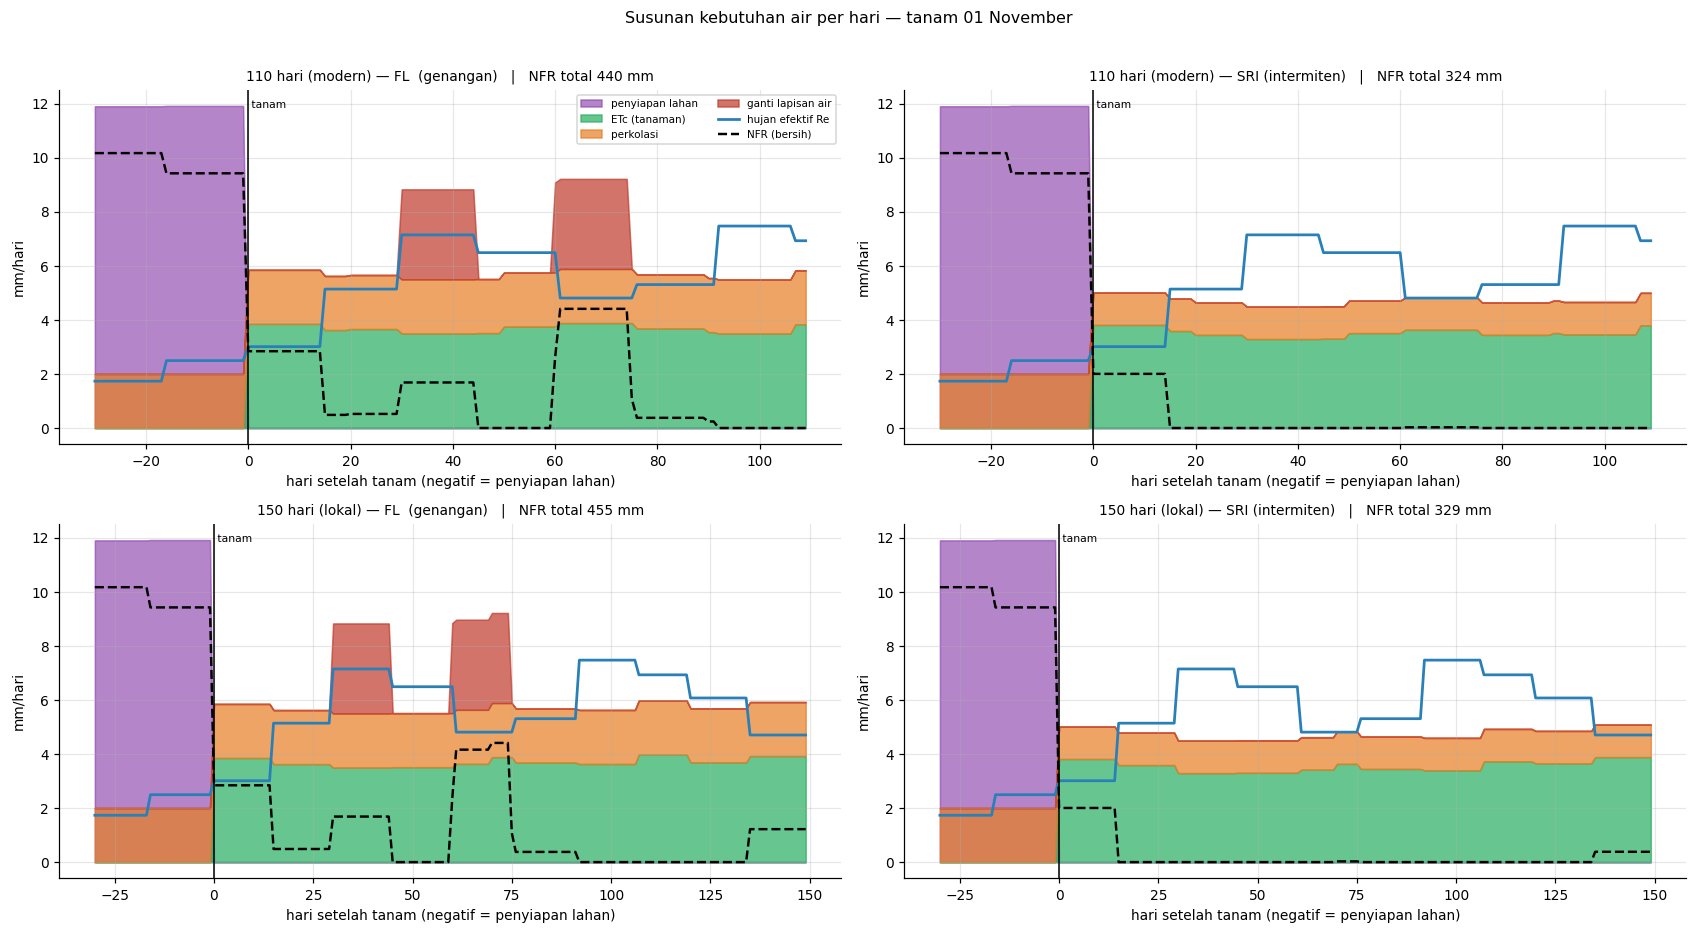

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(15.5, 8.6))
for ax, ((nk, rz), df) in zip(axes.ravel(), musim.items()):
    x = df["hari_ke"]
    etc = df["etc"].fillna(0)
    siap = df["kebutuhan"].where(df["tahap"] == "siap lahan", 0)
    ax.fill_between(x, 0, siap, color="#8e44ad", alpha=0.65, label="penyiapan lahan")
    ax.fill_between(x, 0, etc, color="#27ae60", alpha=0.70, label="ETc (tanaman)")
    ax.fill_between(x, etc, etc+df["perkolasi"], color="#e67e22", alpha=0.70,
                    label="perkolasi")
    ax.fill_between(x, etc+df["perkolasi"], etc+df["perkolasi"]+df["wlr"],
                    color="#c0392b", alpha=0.70, label="ganti lapisan air")
    ax.plot(x, df["re"], color="#2980b9", lw=1.8, label="hujan efektif Re")
    ax.plot(x, df["nfr"], color="black", lw=1.6, ls="--", label="NFR (bersih)")
    ax.axvline(0, color="black", lw=1.0)
    ax.text(0, ax.get_ylim()[1]*0.97, " tanam", fontsize=7, va="top")
    ax.set_xlabel("hari setelah tanam (negatif = penyiapan lahan)")
    ax.set_ylabel("mm/hari")
    ax.set_title(f"{nk} — {rz}   |   NFR total {df['nfr'].sum():,.0f} mm", fontsize=9)
    ax.set_aspect("auto")
axes[0][0].legend(fontsize=6.8, ncol=2, loc="upper right")
fig.suptitle(f"Susunan kebutuhan air per hari — tanam {TANAM_ACUAN:%d %B}", fontsize=10.5)
plt.tight_layout(rect=[0, 0, 1, 0.965])
simpan_gambar(fig, "05_susunan_kebutuhan"); plt.show()

---
## 7. Kapan sebaiknya tanam?

Pertanyaan ini justru yang paling berguna dari seluruh hitungan. Kebutuhan irigasi
sangat bergantung pada **kapan musim dimulai**, karena yang menentukan bukan besarnya
hujan tahunan melainkan **seberapa cocok jadwal tanam dengan datangnya hujan**.

Seluruh 24 tanggal tanam yang mungkin (tiap setengah bulan) dijalankan untuk kedua
kalender dan kedua rezim air. Yang dicari: tanggal yang membuat **kebutuhan irigasi
paling kecil** — dan seberapa besar bedanya dengan tanggal terburuk.

            PENGARUH TANGGAL TANAM TERHADAP KEBUTUHAN IRIGASI
  kalender            rezim                    terbaik    terburuk         selisih
------------------------------------------------------------------------------------
  110 hari (modern)   FL  (genangan)            Des-II      Jul-II        516 mm
  110 hari (modern)   SRI (intermiten)          Des-II      Jul-II        426 mm
  150 hari (lokal)    FL  (genangan)             Des-I       Jun-I        535 mm
  150 hari (lokal)    SRI (intermiten)          Des-II       Jun-I        444 mm
------------------------------------------------------------------------------------
  Contoh (110 hari, genangan):
    tanam Des-II   ->    292 mm  =   14,882 m3
    tanam Jul-II   ->    808 mm  =   41,220 m3
    memilih tanggal yang tepat menghemat 26,338 m3 (64 %)


[gambar] 06_tanggal_tanam.png                   167 KB


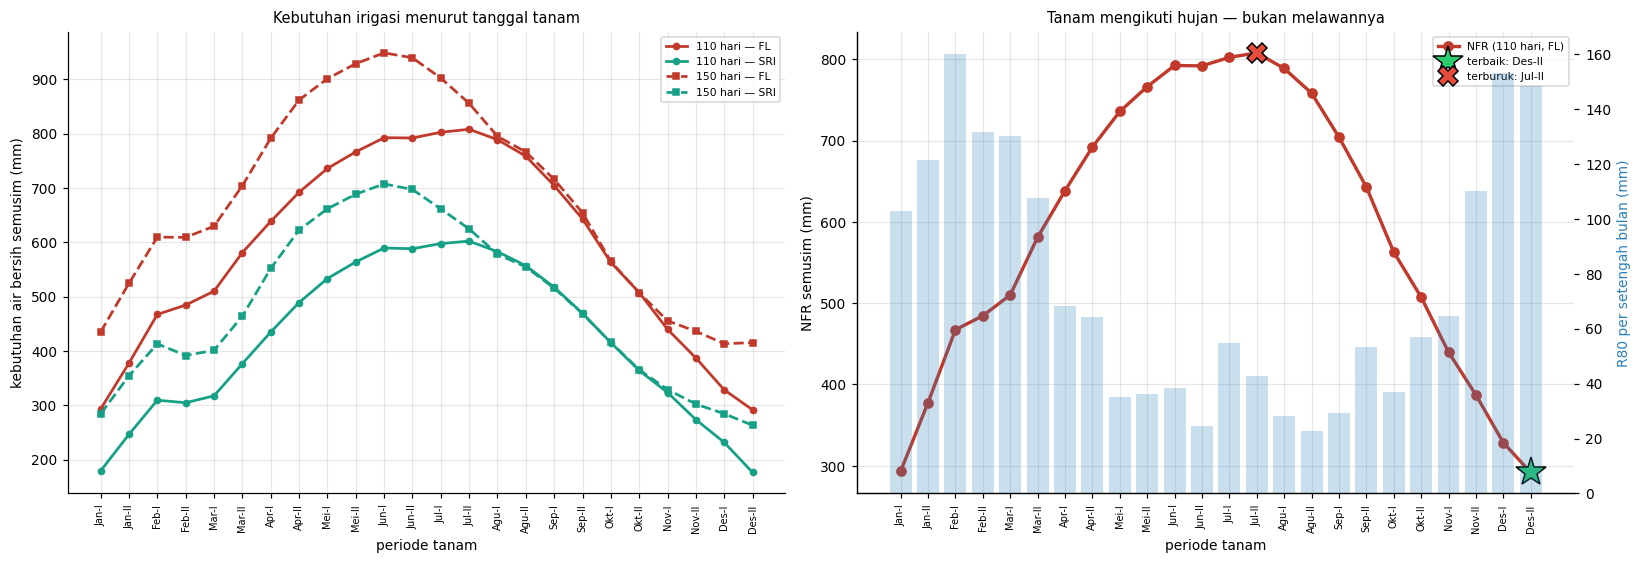

In [10]:
def tanggal_periode(p, tahun=2024):
    """Periode setengah-bulan -> tanggal awalnya."""
    return date(tahun, (p-1)//2 + 1, 1 if p % 2 else 16)

hasil_scan = []
for nk in KALENDER:
    for rz in KC:
        for p in range(1, 25):
            df = hitung_musim(tanggal_periode(p), nk, rz)
            hasil_scan.append({"kalender": nk, "rezim": rz, "periode": p,
                               "label": LBL[p-1], "nfr_mm": df["nfr"].sum(),
                               "q_maks": df["dr_l_s_ha"].max()*LUAS_HA,
                               "volume_m3": df["nfr"].sum()/1000*LUAS_M2/EFISIENSI_IRIGASI})
SC = pd.DataFrame(hasil_scan)

print("=" * 84)
print("            PENGARUH TANGGAL TANAM TERHADAP KEBUTUHAN IRIGASI")
print("=" * 84)
print(f"  {'kalender':<20}{'rezim':<20}{'terbaik':>12}{'terburuk':>12}{'selisih':>16}")
print("-" * 84)
for nk in KALENDER:
    for rz in KC:
        s = SC[(SC.kalender == nk) & (SC.rezim == rz)]
        baik, buruk = s.loc[s.nfr_mm.idxmin()], s.loc[s.nfr_mm.idxmax()]
        print(f"  {nk:<20}{rz:<20}{baik['label']:>12}{buruk['label']:>12}"
              f"{buruk['nfr_mm']-baik['nfr_mm']:>11,.0f} mm")
print("-" * 84)
s_utama = SC[(SC.kalender == "110 hari (modern)") & (SC.rezim == "FL  (genangan)")]
TANAM_BAIK  = s_utama.loc[s_utama.nfr_mm.idxmin()]
TANAM_BURUK = s_utama.loc[s_utama.nfr_mm.idxmax()]
print(f"  Contoh (110 hari, genangan):")
print(f"    tanam {TANAM_BAIK['label']:<8} -> {TANAM_BAIK['nfr_mm']:>6,.0f} mm  "
      f"= {TANAM_BAIK['volume_m3']:>8,.0f} m3")
print(f"    tanam {TANAM_BURUK['label']:<8} -> {TANAM_BURUK['nfr_mm']:>6,.0f} mm  "
      f"= {TANAM_BURUK['volume_m3']:>8,.0f} m3")
print(f"    memilih tanggal yang tepat menghemat {TANAM_BURUK['volume_m3']-TANAM_BAIK['volume_m3']:,.0f} m3 "
      f"({100*(1-TANAM_BAIK['nfr_mm']/TANAM_BURUK['nfr_mm']):.0f} %)")
print("=" * 84)

fig, axes = plt.subplots(1, 2, figsize=(15.0, 5.2))

ax = axes[0]
for nk, mk in zip(KALENDER, ("o-", "s--")):
    for rz, cl in zip(KC, ("#c0392b", "#16a085")):
        s = SC[(SC.kalender == nk) & (SC.rezim == rz)].sort_values("periode")
        ax.plot(s["periode"], s["nfr_mm"], mk, color=cl, lw=1.8, ms=4,
                label=f"{nk.split()[0]} hari — {rz.split()[0]}")
ax.set_xticks(range(1, 25)); ax.set_xticklabels(LBL, rotation=90, fontsize=6.5)
ax.set_ylabel("kebutuhan air bersih semusim (mm)")
ax.set_xlabel("periode tanam")
ax.set_title("Kebutuhan irigasi menurut tanggal tanam", fontsize=9.5)
ax.legend(fontsize=7); ax.set_aspect("auto")

ax = axes[1]
ax2 = ax.twinx()
ax2.bar(range(1, 25), R80.values, alpha=0.25, color="#2980b9", label="hujan andalan R80")
ax2.set_ylabel("R80 per setengah bulan (mm)", color="#2980b9"); ax2.grid(False)
s = SC[(SC.kalender == "110 hari (modern)") & (SC.rezim == "FL  (genangan)")].sort_values("periode")
ax.plot(s["periode"], s["nfr_mm"], "o-", color="#c0392b", lw=2.2, label="NFR (110 hari, FL)")
ax.plot([TANAM_BAIK["periode"]], [TANAM_BAIK["nfr_mm"]], "*", ms=20, mfc="#2ecc71", mec="black", zorder=6,
        label=f"terbaik: {TANAM_BAIK['label']}")
ax.plot([TANAM_BURUK["periode"]], [TANAM_BURUK["nfr_mm"]], "X", ms=13, mfc="#e74c3c", mec="black", zorder=6,
        label=f"terburuk: {TANAM_BURUK['label']}")
ax.set_xticks(range(1, 25)); ax.set_xticklabels(LBL, rotation=90, fontsize=6.5)
ax.set_ylabel("NFR semusim (mm)"); ax.set_xlabel("periode tanam")
ax.set_title("Tanam mengikuti hujan — bukan melawannya", fontsize=9.5)
ax.legend(fontsize=7, loc="upper right"); ax.set_aspect("auto")

plt.tight_layout()
simpan_gambar(fig, "06_tanggal_tanam"); plt.show()

---
## 8. Sensitivitas — angka mana yang paling menentukan?

Ini bagian terpenting untuk riset. Satu angka tunggal tanpa rentang tidak berarti apa-apa;
yang perlu diketahui adalah **asumsi mana yang paling menggerakkan hasil**, karena di
situlah pengukuran lapangan harus diprioritaskan.

Tiap faktor digeser satu per satu dari nilai acuannya, sisanya ditahan tetap.

        SENSITIVITAS — kebutuhan air bersih semusim (acuan 440 mm)
  faktor                                 rendah     tinggi    rentang     pengaruh
------------------------------------------------------------------------------------
  Tanggal tanam terbaik/terburuk            292        808        516         117 %
  Perkolasi 1 -> 4 mm/hari                  362        653        291          66 %
  Sumber hujan ERA5 vs POWER                440        717        278          63 %
  Rezim FL vs SRI                           440        324        116          26 %
  Kalender 110 vs 150 hari                  440        455         16           4 %
  Paling menentukan : Tanggal tanam terbaik/terburuk
  -> di sinilah pengukuran lapangan paling berharga.


[gambar] 07_sensitivitas.png                     99 KB


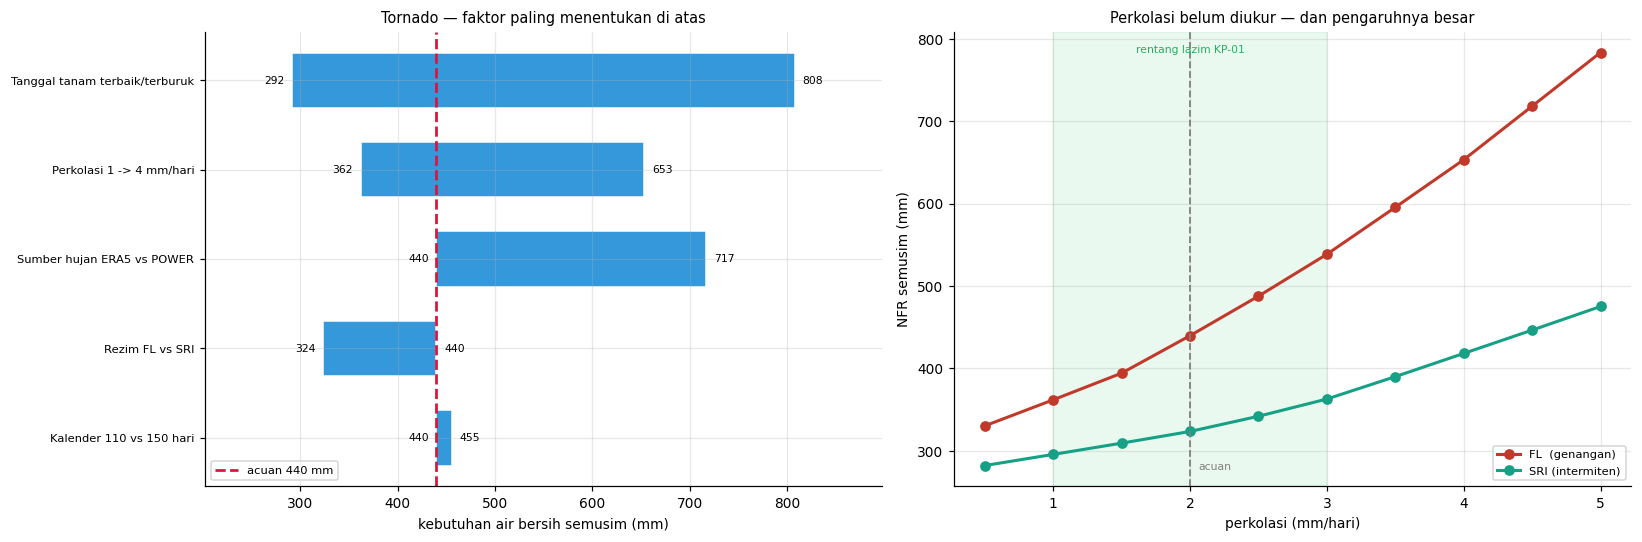

In [11]:
BASIS = dict(kalender="110 hari (modern)", rezim="FL  (genangan)",
             perkolasi=PERKOLASI_MM, efisiensi=EFISIENSI_IRIGASI, re=RE,
             tanam=TANAM_ACUAN)

def nfr_dengan(**ubah):
    o = {**BASIS, **ubah}
    df = hitung_musim(o["tanam"], o["kalender"], o["rezim"],
                      perkolasi=o["perkolasi"], re_seri=o["re"], efisiensi=o["efisiensi"])
    return df["nfr"].sum(), df["nfr"].sum()/1000*LUAS_M2/o["efisiensi"]

nfr0, vol0 = nfr_dengan()

uji = [
    ("Perkolasi 1 -> 4 mm/hari",      nfr_dengan(perkolasi=1.0)[0], nfr_dengan(perkolasi=4.0)[0]),
    ("Sumber hujan ERA5 vs POWER",    nfr0,                          nfr_dengan(re=RE_PW)[0]),
    ("Kalender 110 vs 150 hari",      nfr0,                          nfr_dengan(kalender="150 hari (lokal)")[0]),
    ("Rezim FL vs SRI",               nfr0,                          nfr_dengan(rezim="SRI (intermiten)")[0]),
    ("Tanggal tanam terbaik/terburuk",float(TANAM_BAIK["nfr_mm"]),            float(TANAM_BURUK["nfr_mm"])),
]

print("=" * 84)
print("        SENSITIVITAS — kebutuhan air bersih semusim (acuan "
      f"{nfr0:,.0f} mm)")
print("=" * 84)
print(f"  {'faktor':<34}{'rendah':>11}{'tinggi':>11}{'rentang':>11}{'pengaruh':>13}")
print("-" * 84)
urut = sorted(uji, key=lambda r: -abs(r[2]-r[1]))
for nama, lo, hi in urut:
    print(f"  {nama:<34}{lo:>11,.0f}{hi:>11,.0f}{abs(hi-lo):>11,.0f}"
          f"{100*abs(hi-lo)/nfr0:>12.0f} %")
print("=" * 84)
print(f"  Paling menentukan : {urut[0][0]}")
print(f"  -> di sinilah pengukuran lapangan paling berharga.")
print("=" * 84)

fig, axes = plt.subplots(1, 2, figsize=(15.0, 5.0))

ax = axes[0]
nama = [u[0] for u in urut][::-1]
lo = np.array([min(u[1], u[2]) for u in urut][::-1])
hi = np.array([max(u[1], u[2]) for u in urut][::-1])
ax.barh(range(len(nama)), hi-lo, left=lo, color="#3498db", edgecolor="white", height=0.62)
ax.axvline(nfr0, color="crimson", lw=1.8, ls="--", label=f"acuan {nfr0:,.0f} mm")
for i, (l, h) in enumerate(zip(lo, hi)):
    ax.text(l-8, i, f"{l:,.0f}", va="center", ha="right", fontsize=7)
    ax.text(h+8, i, f"{h:,.0f}", va="center", ha="left", fontsize=7)
ax.set_yticks(range(len(nama))); ax.set_yticklabels(nama, fontsize=7.5)
ax.set_xlabel("kebutuhan air bersih semusim (mm)")
ax.set_title("Tornado — faktor paling menentukan di atas", fontsize=9.5)
ax.legend(fontsize=7.5); ax.set_aspect("auto")
ax.set_xlim(lo.min()-90, hi.max()+90)

ax = axes[1]
for rz, cl in zip(KC, ("#c0392b", "#16a085")):
    v = [nfr_dengan(perkolasi=p, rezim=rz)[0] for p in np.arange(0.5, 5.1, 0.5)]
    ax.plot(np.arange(0.5, 5.1, 0.5), v, "o-", color=cl, lw=2, label=rz)
ax.axvline(PERKOLASI_MM, color="grey", ls="--", lw=1.2)
ax.text(PERKOLASI_MM+0.06, ax.get_ylim()[0]+20, "acuan", fontsize=7, color="grey")
ax.axvspan(1, 3, alpha=0.10, color="#2ecc71")
ax.text(2, ax.get_ylim()[1]*0.98, "rentang lazim KP-01", ha="center", va="top",
        fontsize=7, color="#27ae60")
ax.set_xlabel("perkolasi (mm/hari)"); ax.set_ylabel("NFR semusim (mm)")
ax.set_title("Perkolasi belum diukur — dan pengaruhnya besar", fontsize=9.5)
ax.legend(fontsize=7.5); ax.set_aspect("auto")

plt.tight_layout()
simpan_gambar(fig, "07_sensitivitas"); plt.show()

---
## 9. Neraca air tahunan — apakah hujan saja cukup?

Pertanyaan wajar untuk lahan dengan hujan ~3.000 mm/tahun: **apakah masih perlu irigasi?**

Jawabannya tidak bisa dibaca dari total tahunan, karena hujan **tidak jatuh saat
dibutuhkan**. Yang menentukan adalah kecocokan waktu. Di bawah ini kebutuhan dan hujan
andalan dibandingkan per periode, dan defisitnya dijumlahkan.

Terrain ikut masuk di sini: bagian 9 notebook terrain menemukan daerah tangkapan
**~5 ha** bermuara di titik terendah lahan, padahal lahannya sendiri hanya 3,32 ha —
artinya ada **limpasan dari luar** yang masuk. Itu potensi tambahan air yang diperkirakan
kasar di bawah, dan ditandai jelas sebagai perkiraan.

                     NERACA AIR TAHUNAN
  Hujan andalan R80        :    1,822 mm/tahun
  Hujan efektif (Re)       :    1,275 mm/tahun
  Kebutuhan padi menerus   :    2,027 mm/tahun (ETc + perkolasi, kalau ditanami sepanjang tahun)
------------------------------------------------------------------------------
  Defisit total            :      842 mm  (19 dari 24 periode)
  Surplus total            :       90 mm  (5 dari 24 periode)
------------------------------------------------------------------------------
  Defisit melebihi surplus -> irigasi diperlukan hampir sepanjang tahun.
------------------------------------------------------------------------------
  PERANCANGAN vs PENELITIAN - dua pertanyaan berbeda:
    dengan hujan ANDALAN R80  : defisit    842 mm  <- untuk MERANCANG jaringan
    dengan hujan RATA-RATA    : defisit    392 mm  <- untuk MEMPERKIRAKAN pemakaian
    selisih 450 mm adalah harga keamanan - bukan air yang benar-benar dipakai tiap tahun.
    Kutip yang mana tergant

[gambar] 08_neraca_air.png                      113 KB


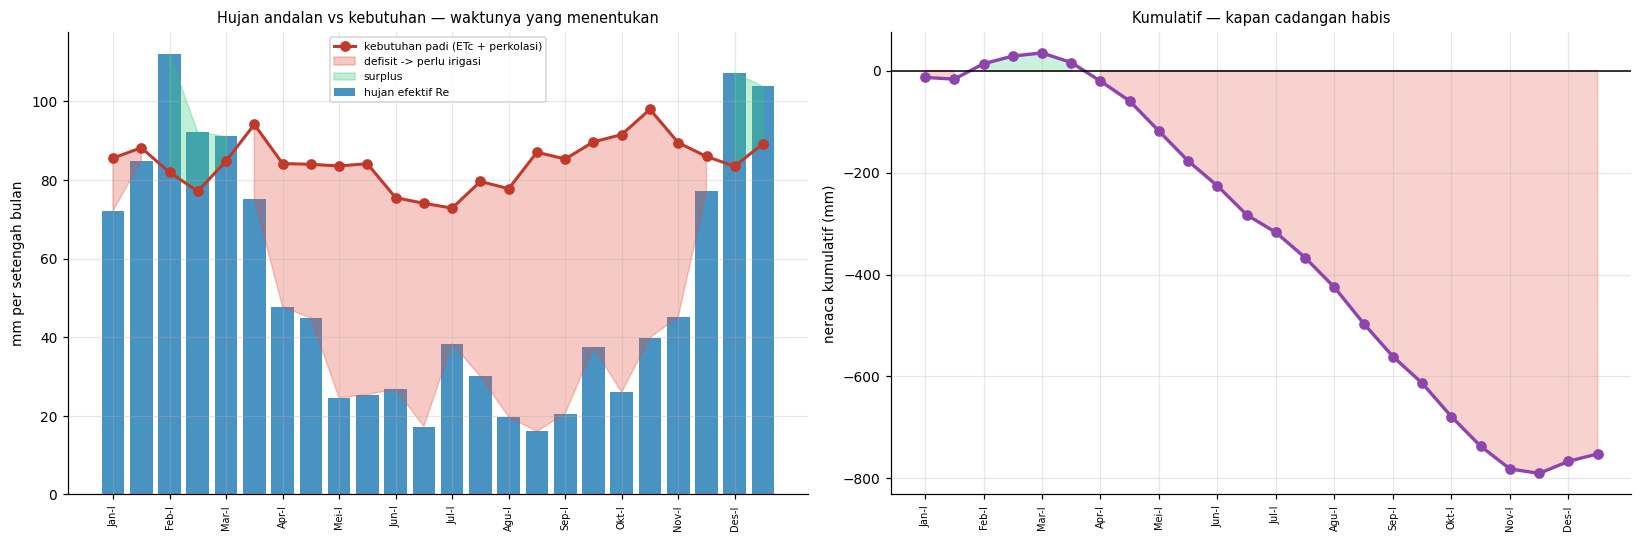

In [12]:
kbt = musim[("110 hari (modern)", "FL  (genangan)")]
keb_per = kbt.groupby("periode")["kebutuhan"].mean()

nb_keb = pd.DataFrame({"R80": R80, "Re": RE*HARI_PERIODE})
nb_keb["ETc_tahunan"] = [float(era.loc[era.periode == p, "eto_pm"].mean())*1.04*HARI_PERIODE[p]
                          for p in nb_keb.index]
nb_keb["keb_padi"] = nb_keb["ETc_tahunan"] + PERKOLASI_MM*HARI_PERIODE
nb_keb["defisit"]  = (nb_keb["keb_padi"] - nb_keb["Re"]).clip(lower=0)
nb_keb["surplus"]  = (nb_keb["Re"] - nb_keb["keb_padi"]).clip(lower=0)

# --- perkiraan kasar limpasan dari luar (ditandai sebagai perkiraan) ---
LUAS_TANGKAP_HA = 4.99            # dari notebook terrain
LUAS_LUAR_HA    = max(LUAS_TANGKAP_HA - LUAS_HA, 0)
KOEF_LIMPASAN   = 0.45            # perkiraan; sawah terasering menahan banyak air
inflow_th = R80.sum()/1000 * LUAS_LUAR_HA*10_000 * KOEF_LIMPASAN

print("=" * 78)
print("                     NERACA AIR TAHUNAN")
print("=" * 78)
print(f"  Hujan andalan R80        : {R80.sum():>8,.0f} mm/tahun")
print(f"  Hujan efektif (Re)       : {nb_keb['Re'].sum():>8,.0f} mm/tahun")
print(f"  Kebutuhan padi menerus   : {nb_keb['keb_padi'].sum():>8,.0f} mm/tahun "
      f"(ETc + perkolasi, kalau ditanami sepanjang tahun)")
print("-" * 78)
print(f"  Defisit total            : {nb_keb['defisit'].sum():>8,.0f} mm  "
      f"({(nb_keb['defisit']>0).sum()} dari 24 periode)")
print(f"  Surplus total            : {nb_keb['surplus'].sum():>8,.0f} mm  "
      f"({(nb_keb['surplus']>0).sum()} dari 24 periode)")
print("-" * 78)
if nb_keb["surplus"].sum() > nb_keb["defisit"].sum():
    print("  Secara TAHUNAN air berlebih. Tetapi kelebihan itu jatuh di musim hujan")
    print("  dan tidak bisa disimpan di petak - jadi defisit musim kemarau TETAP")
    print("  harus dipenuhi irigasi. Total tahunan menyesatkan; yang menentukan waktu.")
else:
    print("  Defisit melebihi surplus -> irigasi diperlukan hampir sepanjang tahun.")
print("-" * 78)
# R80 adalah angka PERANCANGAN (aman 8 dari 10 tahun), bukan perkiraan tahun biasa.
# Untuk meneliti pemakaian air yang sesungguhnya, hujan rata-rata lebih mewakili.
Re_rata  = 0.7*RRAT
def_rata = float((nb_keb["keb_padi"] - Re_rata).clip(lower=0).sum())
print(f"  PERANCANGAN vs PENELITIAN - dua pertanyaan berbeda:")
print(f"    dengan hujan ANDALAN R80  : defisit {nb_keb['defisit'].sum():>6,.0f} mm  "
      f"<- untuk MERANCANG jaringan")
print(f"    dengan hujan RATA-RATA    : defisit {def_rata:>6,.0f} mm  "
      f"<- untuk MEMPERKIRAKAN pemakaian")
print(f"    selisih {nb_keb['defisit'].sum()-def_rata:,.0f} mm adalah harga keamanan"
      f" - bukan air yang benar-benar dipakai tiap tahun.")
print(f"    Kutip yang mana tergantung pertanyaannya. Untuk riset pemakaian air,")
print(f"    angka rata-rata yang mewakili; untuk kapasitas saluran, tetap R80.")
print("-" * 78)
print(f"  PERKIRAAN KASAR limpasan dari luar (bukan hasil ukur):")
print(f"    daerah tangkapan {LUAS_TANGKAP_HA:.2f} ha - lahan {LUAS_HA:.2f} ha "
      f"= {LUAS_LUAR_HA:.2f} ha dari luar")
print(f"    x R80 {R80.sum():,.0f} mm x koefisien limpasan {KOEF_LIMPASAN:.2f}")
print(f"    ~ {inflow_th:,.0f} m3/tahun masuk ke lahan tanpa diminta")
print(f"    (sebagai perbandingan, satu musim tanam butuh "
      f"~{RM['volume_m3'].min():,.0f}-{RM['volume_m3'].max():,.0f} m3)")
print("  Koefisien 0,45 adalah TEBAKAN literatur, bukan pengukuran. Angka ini hanya")
print("  untuk menunjukkan bahwa sumbernya ADA dan layak diukur - bukan untuk dipakai.")
print("=" * 78)

fig, axes = plt.subplots(1, 2, figsize=(15.0, 5.0))

ax = axes[0]
xs = np.arange(1, 25)
ax.bar(xs, nb_keb["Re"], color="#2980b9", alpha=0.85, label="hujan efektif Re")
ax.plot(xs, nb_keb["keb_padi"], "o-", color="#c0392b", lw=2,
        label="kebutuhan padi (ETc + perkolasi)")
ax.fill_between(xs, nb_keb["Re"], nb_keb["keb_padi"],
                where=(nb_keb["keb_padi"] > nb_keb["Re"]), color="#e74c3c", alpha=0.30,
                label="defisit -> perlu irigasi")
ax.fill_between(xs, nb_keb["Re"], nb_keb["keb_padi"],
                where=(nb_keb["keb_padi"] <= nb_keb["Re"]), color="#2ecc71", alpha=0.30,
                label="surplus")
ax.set_xticks(xs[::2]); ax.set_xticklabels(LBL[::2], rotation=90, fontsize=6.5)
ax.set_ylabel("mm per setengah bulan")
ax.set_title("Hujan andalan vs kebutuhan — waktunya yang menentukan", fontsize=9.5)
ax.legend(fontsize=7); ax.set_aspect("auto")

ax = axes[1]
kum = (nb_keb["Re"] - nb_keb["keb_padi"]).cumsum()
ax.plot(xs, kum, "o-", color="#8e44ad", lw=2.2)
ax.fill_between(xs, 0, kum, where=(kum >= 0), color="#2ecc71", alpha=0.25)
ax.fill_between(xs, 0, kum, where=(kum < 0), color="#e74c3c", alpha=0.25)
ax.axhline(0, color="black", lw=1)
ax.set_xticks(xs[::2]); ax.set_xticklabels(LBL[::2], rotation=90, fontsize=6.5)
ax.set_ylabel("neraca kumulatif (mm)")
ax.set_title("Kumulatif — kapan cadangan habis", fontsize=9.5)
ax.set_aspect("auto")

plt.tight_layout()
simpan_gambar(fig, "08_neraca_air"); plt.show()

---
## 10. Sebaran menurut pita ketinggian — bulan pertama

Batas petak tidak ada di KML, jadi peta per-petak tidak mungkin dibuat. Sebagai
gantinya lahan diiris menjadi **pita ketinggian setebal 1 m**, dibaca dari DEM.

Ini bukan sekadar akal-akalan pengganti. Pada lahan terasering, **ketinggian justru
prinsip penyusunnya**: satu teras menempati satu rentang elevasi yang sempit, dan air
masuk dari petak tertinggi lalu turun bertingkat. Jadi satu pita 1 m adalah wakil yang
masuk akal untuk "sekelompok teras yang setara" — bahkan lebih bermakna daripada petak
persegi kalau petaknya digambar sembarang.

**Bulan pertama = 30 hari penyiapan lahan**, dan itu dipilih bukan karena urutannya
melainkan karena di situlah **puncak pemakaian air** (11,54 mm/hari, 3,1× ETc puncak).
Kalau ada bulan yang menentukan kapasitas saluran, bulan inilah.

### Cara membaca ketiga peta panas

| Peta | Isi | Yang menggerakkan |
|---|---|---|
| **Penggunaan air** | m³/hari yang dipakai tiap pita | **luas pita** — pita lebar butuh lebih banyak |
| **Water loss** | m³/hari yang hilang: menguap + meresap + melimpas | luas pita × laju kehilangan |
| **Debit lewat pita** | l/detik yang harus **mengalir melewati** pita itu | penumpukan bertingkat dari atas |

Peta ketiga yang paling berbeda sifatnya. Air masuk dari atas, jadi aliran yang tiba di
suatu pita harus masih cukup untuk melayani **pita itu dan semua pita di bawahnya**:

$$Q(b)=\sum_{b'\le b} \text{kebutuhan}(b')$$

Akibatnya pita teratas menanggung **seluruh** debit lahan, sedangkan pita terbawah hanya
menanggung kebutuhannya sendiri. Inilah alasan pintu masuk harus berada di puncak — dan
alasan saluran di bagian atas harus berkapasitas besar sementara di bawah boleh kecil.

Sumbu tegak sengaja **naik ke atas**: pita terendah (~600 m) di dasar gambar, tertinggi
(~624 m) di puncak — sama seperti lahannya berdiri di lapangan.

In [13]:
# ---------- pita ketinggian 1 m dari DEM ----------
grid = pd.read_csv(DIR_TER / "terrain_grid.csv")
RES_DEM  = float(TER["resolusi_grid_dem_m"])
LUAS_SEL = RES_DEM**2

grid["pita"] = np.floor(grid["elev_m"]).astype(int)
pita = grid.groupby("pita").agg(n_sel=("elev_m", "size"),
                                lereng=("lereng_persen", "mean")).sort_index()
# Luas pita diskalakan ke luas POLIGON. Menghitung sel DEM saja memberi 33.358 m2,
# sedangkan batas KML 33.163 m2 - selisih 0,6 % semata akibat pembulatan sel ke kisi.
# Yang berwenang adalah batas poligon, jadi pita disesuaikan ke situ. Tanpa langkah ini
# debit hasil bagian ini tidak akan pernah persis sama dengan bagian 6.
luas_sel_total  = pita["n_sel"].sum()*LUAS_SEL
pita["luas_m2"] = pita["n_sel"]*LUAS_SEL*(LUAS_M2/luas_sel_total)
pita["luas_pct"] = 100*pita["luas_m2"]/pita["luas_m2"].sum()
PITA = pita.index.values                     # menaik: bawah -> atas

# ---------- bulan pertama = 30 hari penyiapan lahan ----------
MUSIM_ACUAN = musim[("110 hari (modern)", "FL  (genangan)")]
bulan1 = MUSIM_ACUAN[MUSIM_ACUAN["tahap"] == "siap lahan"].reset_index(drop=True)
HARI = np.arange(1, len(bulan1)+1)

# komponen per satuan luas (mm/hari) - sama untuk semua pita
eo_mm    = 1.1*bulan1["eto"].values                       # menguap (Eo penyiapan lahan)
perk_mm  = bulan1["perkolasi"].values                     # meresap
hujan_mm = bulan1["re"].values/0.7                        # hujan andalan harian
limp_mm  = hujan_mm - bulan1["re"].values                 # melimpas (30 % tak efektif)
nfr_mm   = bulan1["nfr"].values                           # yang harus diberi irigasi

def ke_m3(mm_harian):
    """(mm/hari) x (luas pita) -> matriks m3/hari [pita x hari]."""
    return np.outer(pita["luas_m2"].values, mm_harian)/1000.0

M_pakai = ke_m3(nfr_mm)
M_uap, M_resap, M_limpas = ke_m3(eo_mm), ke_m3(perk_mm), ke_m3(limp_mm)
M_loss  = M_uap + M_resap + M_limpas

# ---------- debit bertingkat: aliran yang lewat tiap pita ----------
# Q(b) = jumlah kebutuhan pita b dan SEMUA pita di bawahnya, dalam l/detik kotor.
M_kotor  = M_pakai/EFISIENSI_IRIGASI
M_debit  = np.cumsum(M_kotor, axis=0)*1000/86400          # m3/hari -> l/detik

print("=" * 78)
print(f"   PITA KETINGGIAN 1 m — {len(PITA)} pita, {PITA.min()}–{PITA.max()+1} m dpl")
print("=" * 78)
print(f"  {'pita (m dpl)':<16}{'luas (m2)':>12}{'% lahan':>10}{'lereng %':>11}"
      f"{'pakai (m3)':>13}{'loss (m3)':>12}")
print("-" * 78)
for i, pb in enumerate(PITA[::-1]):                       # cetak dari ATAS ke bawah
    k = len(PITA)-1-i
    print(f"  {pb}-{pb+1:<11}{pita['luas_m2'].iloc[k]:>12,.0f}"
          f"{pita['luas_pct'].iloc[k]:>10.1f}{pita['lereng'].iloc[k]:>11.1f}"
          f"{M_pakai[k].sum():>13,.0f}{M_loss[k].sum():>12,.0f}")
print("-" * 78)
print(f"  {'TOTAL':<16}{pita['luas_m2'].sum():>12,.0f}{100:>10.1f}"
      f"{'':>11}{M_pakai.sum():>13,.0f}{M_loss.sum():>12,.0f}")
print("=" * 78)
pita_lebar = pita["luas_m2"].idxmax()
print(f"  Pita terlebar : {pita_lebar}-{pita_lebar+1} m dpl "
      f"({pita['luas_m2'].max():,.0f} m2 = {pita['luas_pct'].max():.1f} % lahan)")
print(f"  -> pita ini menyerap air paling banyak, bukan karena lebih haus")
print(f"     melainkan semata karena paling luas.")
print("-" * 78)
q_puncak_atas = M_debit[-1].max()
print(f"  Debit lewat pita TERATAS (puncak) : {q_puncak_atas:.2f} l/detik")
print(f"  Debit lewat pita TERBAWAH (puncak): {M_debit[0].max():.2f} l/detik")
selisih_uji = abs(q_puncak_atas - RM['q_maks_l_s'].max())
print(f"  Uji silang dengan bagian 6 ({RM['q_maks_l_s'].max():.2f} l/detik): "
      f"selisih {selisih_uji:.3f} l/detik "
      f"-> {'COCOK' if selisih_uji < 0.02 else 'PERIKSA'}")
# Di ketinggian berapa debitnya tinggal separuh? Ini yang berguna untuk menakar
# saluran - bukan nisbah puncak/dasar, karena pita terbawah hanya serpihan kecil.
puncak_kolom = M_debit[:, M_debit.max(axis=0).argmax()]
i_separuh = int(np.searchsorted(puncak_kolom, puncak_kolom[-1]/2))
print(f"  Debit tinggal SEPARUH di sekitar {PITA[i_separuh]} m dpl "
      f"({100*(PITA[i_separuh]-PITA.min())/(PITA.max()-PITA.min()):.0f} % tinggi lahan)")
print(f"  -> saluran boleh menyusut mulai dari situ ke bawah; di atasnya tidak.")
print("=" * 78)

   PITA KETINGGIAN 1 m — 26 pita, 599–625 m dpl
  pita (m dpl)       luas (m2)   % lahan   lereng %   pakai (m3)   loss (m3)
------------------------------------------------------------------------------
  624-625                 111       0.3        3.9           33          24
  623-624               1,157       3.5        6.3          339         252
  622-623               1,045       3.2        8.8          306         228
  621-622               1,179       3.6        9.0          346         257
  620-621               2,246       6.8        7.3          658         490
  619-620               1,557       4.7       10.1          456         339
  618-619               1,357       4.1       11.3          398         296
  617-618               1,935       5.8       10.6          567         422
  616-617               1,690       5.1       11.9          495         369
  615-616               1,868       5.6       11.8          548         407
  614-615               2,113       

C:\Users\fadel\AppData\Local\Temp\ipykernel_27976\1434235767.py:41: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.94])


[gambar] 09_pita_elevasi_bulan1.png              91 KB


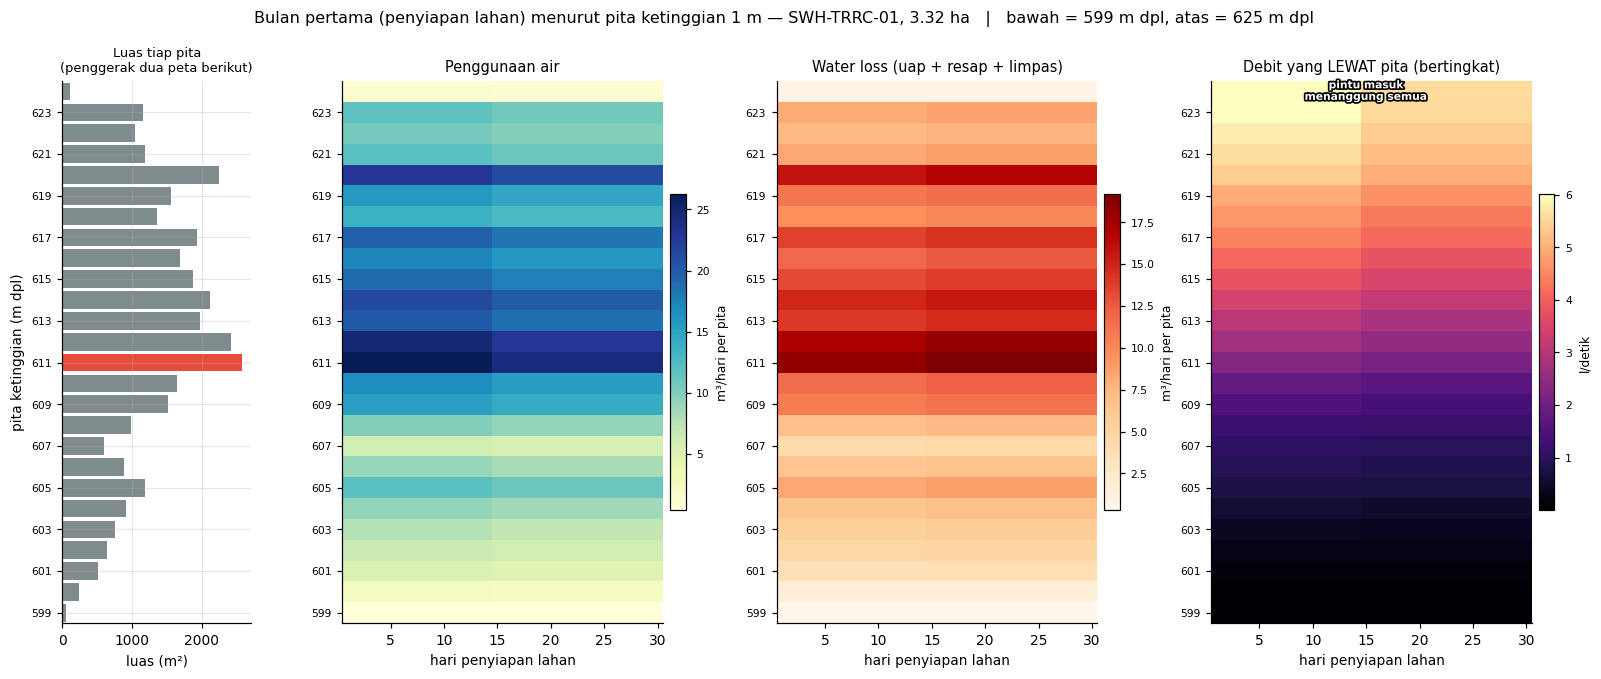

In [14]:
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(17.5, 6.4))
gs  = GridSpec(1, 4, width_ratios=[0.55, 1, 1, 1], wspace=0.30)
yy  = np.arange(len(PITA))

def peta_panas(ax, M, judul, satuan, cmap, fmt="{:.0f}"):
    im = ax.pcolormesh(HARI, yy, M, cmap=cmap, shading="nearest")
    cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
    cb.set_label(satuan, fontsize=8); cb.ax.tick_params(labelsize=7)
    ax.set_xlabel("hari penyiapan lahan")
    ax.set_yticks(yy[::2]); ax.set_yticklabels([f"{b}" for b in PITA[::2]], fontsize=7)
    ax.set_title(judul, fontsize=9.5)
    ax.grid(False); ax.set_aspect("auto")
    return im

# --- profil luas: penjelas semua peta di kanannya ---
ax = fig.add_subplot(gs[0, 0])
ax.barh(yy, pita["luas_m2"].values, color="#7f8c8d", height=0.85)
ax.barh([len(PITA)-1-list(PITA[::-1]).index(pita_lebar)], [pita["luas_m2"].max()],
        color="#e74c3c", height=0.85)
ax.set_yticks(yy[::2]); ax.set_yticklabels([f"{b}" for b in PITA[::2]], fontsize=7)
ax.set_ylabel("pita ketinggian (m dpl)")
ax.set_xlabel("luas (m²)")
ax.set_title("Luas tiap pita\n(penggerak dua peta berikut)", fontsize=8.5)
ax.set_ylim(-0.5, len(PITA)-0.5); ax.set_aspect("auto")

peta_panas(fig.add_subplot(gs[0, 1]), M_pakai,
           "Penggunaan air", "m³/hari per pita", "YlGnBu")
peta_panas(fig.add_subplot(gs[0, 2]), M_loss,
           "Water loss (uap + resap + limpas)", "m³/hari per pita", "OrRd")
axq = fig.add_subplot(gs[0, 3])
peta_panas(axq, M_debit, "Debit yang LEWAT pita (bertingkat)", "l/detik", "magma")
axq.annotate("pintu masuk\nmenanggung semua", xy=(len(HARI)*0.5, len(PITA)-1.4),
             fontsize=7, color="white", ha="center", weight="bold",
             path_effects=[pe.withStroke(linewidth=2.2, foreground="black")])

fig.suptitle(f"Bulan pertama (penyiapan lahan) menurut pita ketinggian 1 m — "
             f"{TER['nama_lahan']}, {LUAS_HA:.2f} ha   |   bawah = {PITA.min()} m dpl, "
             f"atas = {PITA.max()+1} m dpl", fontsize=10.5)
plt.tight_layout(rect=[0, 0, 1, 0.94])
simpan_gambar(fig, "09_pita_elevasi_bulan1"); plt.show()

[gambar] 10_water_loss_komponen.png              92 KB


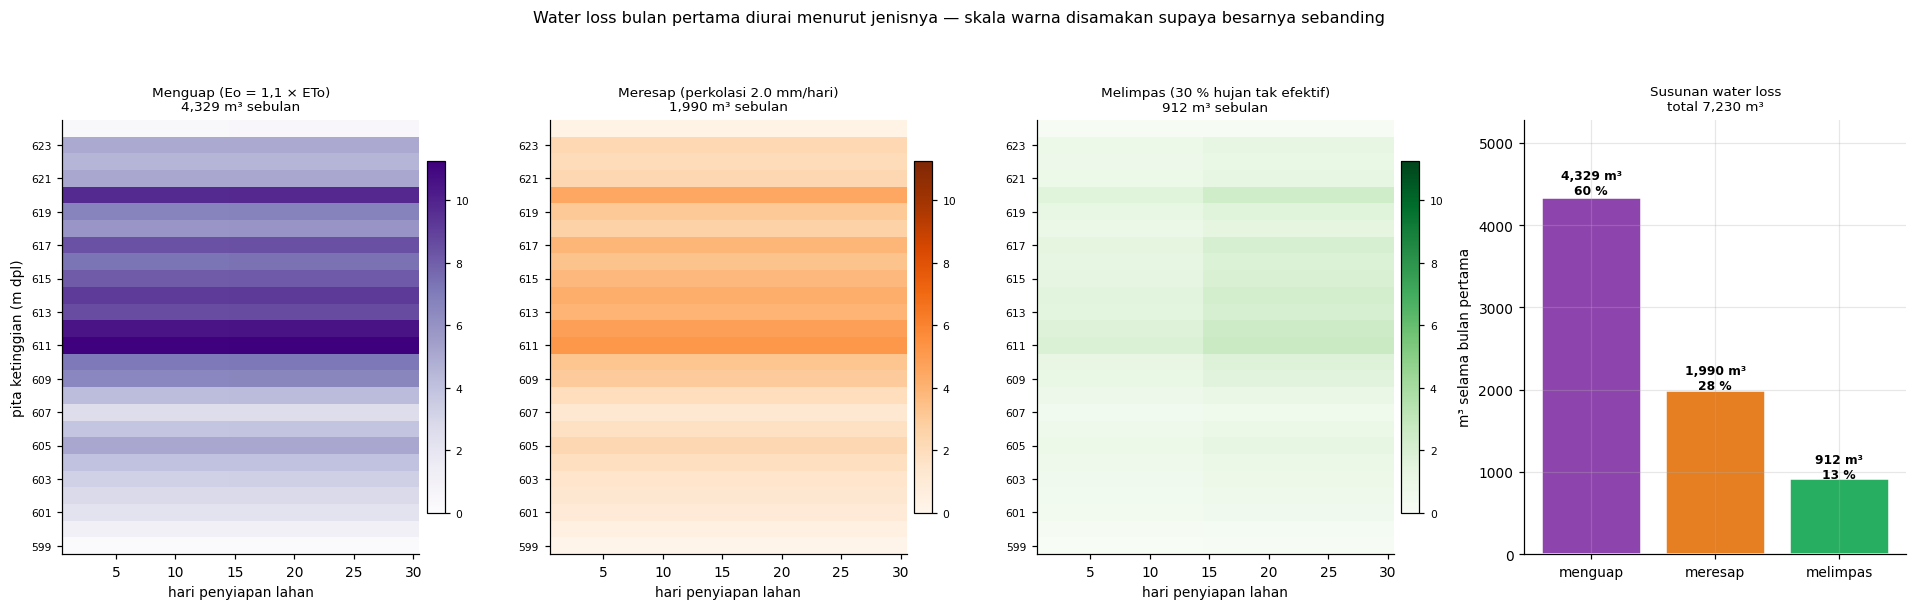

            WATER LOSS BULAN PERTAMA (30 hari penyiapan lahan)
  menguap     :     4,329 m3  (59.9 %)  =  130.5 mm
  meresap     :     1,990 m3  (27.5 %)  =   60.0 mm
  melimpas    :       912 m3  (12.6 %)  =   27.5 mm
------------------------------------------------------------------------------
  TOTAL loss  :     7,230 m3            =  218.0 mm
  Penggunaan  :     9,721 m3            =  293.1 mm  (irigasi bersih)
------------------------------------------------------------------------------
  Kehilangan terbesar: MENGUAP (60 % dari total)


,n_sel,lereng,luas_m2,luas_pct,pakai_m3_bulan1,loss_m3_bulan1,menguap_m3,meresap_m3,melimpas_m3,debit_lewat_maks_l_s
pita,,,,,,,,,,
599,2,9.8,44.5,0.1,13.0,9.7,5.8,2.7,1.2,0.0
600,11,11.2,244.7,0.7,71.7,53.3,31.9,14.7,6.7,0.1
601,23,13.1,511.6,1.5,149.9,111.5,66.8,30.7,14.1,0.1
602,29,14.5,645.0,1.9,189.1,140.6,84.2,38.7,17.7,0.3
603,34,15.2,756.2,2.3,221.7,164.9,98.7,45.4,20.8,0.4
604,41,16.0,911.9,2.7,267.3,198.8,119.0,54.7,25.1,0.6
605,53,13.0,1178.8,3.6,345.5,257.0,153.9,70.7,32.4,0.8
606,40,14.8,889.7,2.7,260.8,194.0,116.1,53.4,24.5,0.9
607,27,17.4,600.5,1.8,176.0,130.9,78.4,36.0,16.5,1.0


In [15]:
fig, axes = plt.subplots(1, 4, figsize=(17.5, 5.6))
vmaks = max(M_uap.max(), M_resap.max(), M_limpas.max())

for ax, (M, jd, cm) in zip(axes[:3], [
        (M_uap,    f"Menguap (Eo = 1,1 × ETo)\n{M_uap.sum():,.0f} m³ sebulan",    "Purples"),
        (M_resap,  f"Meresap (perkolasi {PERKOLASI_MM:.1f} mm/hari)\n{M_resap.sum():,.0f} m³ sebulan", "Oranges"),
        (M_limpas, f"Melimpas (30 % hujan tak efektif)\n{M_limpas.sum():,.0f} m³ sebulan", "Greens")]):
    im = ax.pcolormesh(HARI, np.arange(len(PITA)), M, cmap=cm, shading="nearest",
                       vmin=0, vmax=vmaks)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.02).ax.tick_params(labelsize=7)
    ax.set_xlabel("hari penyiapan lahan")
    ax.set_yticks(np.arange(len(PITA))[::2])
    ax.set_yticklabels([f"{b}" for b in PITA[::2]], fontsize=7)
    ax.set_title(jd, fontsize=8.8); ax.grid(False); ax.set_aspect("auto")
axes[0].set_ylabel("pita ketinggian (m dpl)")

ax = axes[3]
tot = [M_uap.sum(), M_resap.sum(), M_limpas.sum()]
nm  = ["menguap", "meresap", "melimpas"]
wr  = ["#8e44ad", "#e67e22", "#27ae60"]
ax.bar(nm, tot, color=wr, edgecolor="white")
for i, v in enumerate(tot):
    ax.text(i, v*1.01, f"{v:,.0f} m³\n{100*v/sum(tot):.0f} %", ha="center",
            fontsize=8, weight="bold")
ax.set_ylabel("m³ selama bulan pertama")
ax.set_title(f"Susunan water loss\ntotal {sum(tot):,.0f} m³", fontsize=8.8)
ax.set_ylim(0, max(tot)*1.22); ax.set_aspect("auto")

fig.suptitle("Water loss bulan pertama diurai menurut jenisnya — skala warna disamakan "
             "supaya besarnya sebanding", fontsize=10.5)
plt.tight_layout(rect=[0, 0, 1, 0.93])
simpan_gambar(fig, "10_water_loss_komponen"); plt.show()

# ---------- simpan tabel pita ----------
tab = pita.copy()
tab["pakai_m3_bulan1"] = M_pakai.sum(axis=1)
tab["loss_m3_bulan1"]  = M_loss.sum(axis=1)
tab["menguap_m3"] = M_uap.sum(axis=1)
tab["meresap_m3"] = M_resap.sum(axis=1)
tab["melimpas_m3"] = M_limpas.sum(axis=1)
tab["debit_lewat_maks_l_s"] = M_debit.max(axis=1)
tab.reset_index().to_csv(OUT_DIR / "pita_elevasi_bulan1.csv", index=False)

print("=" * 78)
print("            WATER LOSS BULAN PERTAMA (30 hari penyiapan lahan)")
print("=" * 78)
for n, v in zip(nm, tot):
    print(f"  {n:<12}: {v:>9,.0f} m3  ({100*v/sum(tot):>4.1f} %)  "
          f"= {v/LUAS_M2*1000:>6.1f} mm")
print("-" * 78)
print(f"  {'TOTAL loss':<12}: {sum(tot):>9,.0f} m3            "
      f"= {sum(tot)/LUAS_M2*1000:>6.1f} mm")
print(f"  {'Penggunaan':<12}: {M_pakai.sum():>9,.0f} m3            "
      f"= {M_pakai.sum()/LUAS_M2*1000:>6.1f} mm  (irigasi bersih)")
print("-" * 78)
print(f"  Kehilangan terbesar: {nm[int(np.argmax(tot))].upper()} "
      f"({100*max(tot)/sum(tot):.0f} % dari total)")
if np.argmax(tot) == 1:
    print(f"  Perkolasi mendominasi -> dan nilainya BELUM DIUKUR (asumsi "
          f"{PERKOLASI_MM:.1f} mm/hari).")
    print(f"  Inilah alasan uji perkolasi jadi pekerjaan lapangan berimbal-hasil tertinggi.")
print("=" * 78)
tab.round(1)

### 10b. Peta panas yang sama, ditumpuk di atas citra

Peta panas di atas mudah dibaca angkanya tapi kehilangan **letak**. Di sini nilai yang
persis sama dipulangkan ke ruang aslinya: tiap sel DEM diwarnai menurut **pita
ketinggian tempatnya berada**, lalu ditumpuk di atas citra satelit.

Dimensi waktu dilipat — yang ditampilkan **total sebulan** (dan debit puncak), karena
satu peta tidak bisa memuat 30 hari sekaligus. Untuk pola hariannya, baca peta panas
sebelumnya.

> **Warnanya nilai PER PITA, bukan per titik.** Dua sel di pita yang sama selalu berwarna
> sama, betapa pun jauh jaraknya. Jadi peta ini menjawab "pita mana yang memakai paling
> banyak", **bukan** "titik mana yang paling haus" — model ini memang belum membedakan
> kebutuhan antar-titik di dalam satu pita.

In [16]:
import io as _io, re as _re, urllib.request as _url
from PIL import Image
from matplotlib.colors import BoundaryNorm

# ---------- transformasi dipulihkan DARI DATA, bukan dihitung ulang ----------
# terrain_grid.csv memuat lon/lat dan x_m/y_m sekaligus, jadi tetapannya bisa
# dicocokkan langsung. Cara ini menjamin peta di sini berimpit persis dengan
# notebook terrain - tidak ada peluang salah acuan.
mlon, clon = np.polyfit(grid["lon"], grid["x_m"], 1)
mlat, clat = np.polyfit(grid["lat"], grid["y_m"], 1)
LON0, LAT0 = -clon/mlon, -clat/mlat
print(f"Acuan proyeksi dipulihkan: {LAT0:.6f} LS, {LON0:.6f} BT")
print(f"  1 deg bujur = {mlon:,.1f} m | 1 deg lintang = {mlat:,.1f} m")

# ---------- batas lahan dari KML ----------
raw_kml = (ROOT / "SWH-TRRC-011.kml").read_text(encoding="utf-8")
blok = max(_re.findall(r"<coordinates>(.*?)</coordinates>", raw_kml, _re.S), key=len)
ring_ll = [tuple(map(float, t.split(",")[:2])) for t in blok.split()]
BX = np.array([(lo-LON0)*mlon for lo, la in ring_ll])
BY = np.array([(la-LAT0)*mlat for lo, la in ring_ll])

# ---------- raster nilai per pita ----------
xs_u, ys_u = np.sort(grid["x_m"].unique()), np.sort(grid["y_m"].unique())
ix = np.searchsorted(xs_u, grid["x_m"].values)
iy = np.searchsorted(ys_u, grid["y_m"].values)
EXT = [xs_u.min()-RES_DEM/2, xs_u.max()+RES_DEM/2,
       ys_u.min()-RES_DEM/2, ys_u.max()+RES_DEM/2]

def rasterkan(nilai_per_pita):
    """dict/Series {pita: nilai} -> raster 2D (NaN di luar lahan)."""
    R = np.full((len(ys_u), len(xs_u)), np.nan)
    R[iy, ix] = grid["pita"].map(nilai_per_pita).values
    return R

R_pita   = rasterkan(pd.Series(PITA, index=PITA))
R_pakai  = rasterkan(tab["pakai_m3_bulan1"])
R_loss   = rasterkan(tab["loss_m3_bulan1"])
R_debit  = rasterkan(tab["debit_lewat_maks_l_s"])

# ---------- citra satelit dari cache ----------
TILE_DIR = ROOT / "note" / "output" / "tiles"
TILE_URL = ("https://server.arcgisonline.com/ArcGIS/rest/services/"
            "World_Imagery/MapServer/tile/{z}/{y}/{x}")
KREDIT = "Citra: Esri, Maxar, Earthstar Geographics"
ZOOM_PETA = 18

def _ll2px(lo, la, z):
    n = 256*2**z
    return ((lo+180)/360*n,
            (1 - math.log(math.tan(math.radians(la)) + 1/math.cos(math.radians(la)))/math.pi)/2*n)
def _px2ll(px, py, z):
    n = 256*2**z
    return (px/n*360-180, math.degrees(math.atan(math.sinh(math.pi*(1-2*py/n)))))

def susun_citra(z=ZOOM_PETA, margin_m=45.0):
    lo_, la_ = np.array([p[0] for p in ring_ll]), np.array([p[1] for p in ring_ll])
    dlo, dla = margin_m/mlon, margin_m/mlat
    px0, py0 = _ll2px(lo_.min()-dlo, la_.max()+dla, z)
    px1, py1 = _ll2px(lo_.max()+dlo, la_.min()-dla, z)
    tx0, ty0, tx1, ty1 = int(px0//256), int(py0//256), int(px1//256), int(py1//256)
    kan = np.zeros(((ty1-ty0+1)*256, (tx1-tx0+1)*256, 3), np.uint8)
    for ty in range(ty0, ty1+1):
        for tx in range(tx0, tx1+1):
            f = TILE_DIR / f"{z}_{tx}_{ty}.jpg"
            if not f.exists():                       # cache notebook terrain dipakai ulang
                with _url.urlopen(_url.Request(TILE_URL.format(z=z, x=tx, y=ty),
                                               headers=UA), timeout=25) as r:
                    f.write_bytes(r.read())
            kan[(ty-ty0)*256:(ty-ty0+1)*256,
                (tx-tx0)*256:(tx-tx0+1)*256] = np.asarray(Image.open(f).convert("RGB"))
    a, b_ = _px2ll(tx0*256, ty0*256, z)
    c, d_ = _px2ll((tx1+1)*256, (ty1+1)*256, z)
    return kan, [(a-LON0)*mlon, (c-LON0)*mlon, (d_-LAT0)*mlat, (b_-LAT0)*mlat]

try:
    CITRA_IMG, CITRA_EXT = susun_citra()
    print(f"Citra siap: {CITRA_IMG.shape[1]}x{CITRA_IMG.shape[0]} piksel (z{ZOOM_PETA})")
except Exception as e:
    CITRA_IMG = CITRA_EXT = None
    print(f"Citra tidak tersedia ({type(e).__name__}) - peta digambar tanpa latar")

Acuan proyeksi dipulihkan: -8.371211 LS, 115.137653 BT
  1 deg bujur = 110,141.8 m | 1 deg lintang = 110,597.5 m
Citra siap: 768x768 piksel (z18)


[gambar] 11_pita_overlay_citra.png              660 KB


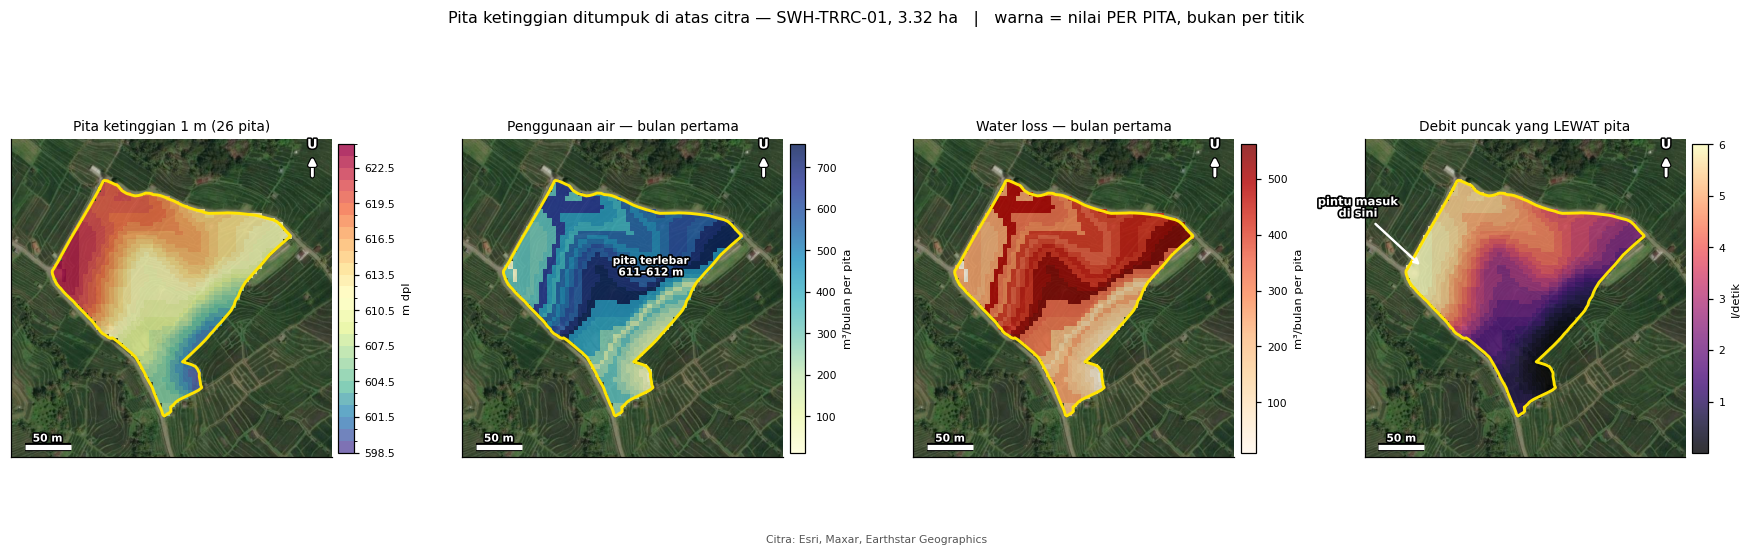

  MEMBACA KEEMPAT PETA
  1. Pita ketinggian : 26 pita dari 599 sampai 625 m dpl.
     Pita rapat = lereng curam; pita lebar = bidang landai.
  2. Penggunaan air  : paling pekat di pita 611-612 m (756 m3),
     semata karena pita itu paling luas (2,580 m2).
  3. Water loss      : berpola sama - digerakkan luas, bukan posisi lereng.
  4. Debit lewat     : gradien dari 6.01 l/detik di puncak
     turun ke 0.01 l/detik di dasar. Inilah peta yang paling
     berguna: menunjukkan di mana saluran harus besar dan di mana boleh kecil.


In [17]:
def batang_skala(ax, x0, y0, panjang=50):
    ax.plot([x0, x0+panjang], [y0, y0], color="white", lw=3.4, solid_capstyle="butt",
            path_effects=[pe.withStroke(linewidth=5.4, foreground="black")], zorder=9)
    ax.text(x0+panjang/2, y0+4, f"{panjang} m", ha="center", va="bottom", fontsize=7,
            color="white", weight="bold", zorder=9,
            path_effects=[pe.withStroke(linewidth=2, foreground="black")])

def panah_utara(ax):
    ax.annotate("", xy=(0.94, 0.955), xytext=(0.94, 0.875), xycoords="axes fraction",
                zorder=9, arrowprops=dict(arrowstyle="-|>", color="white", lw=1.9,
                path_effects=[pe.withStroke(linewidth=3.4, foreground="black")]))
    ax.text(0.94, 0.962, "U", transform=ax.transAxes, ha="center", va="bottom",
            fontsize=8.5, color="white", weight="bold", zorder=9,
            path_effects=[pe.withStroke(linewidth=2, foreground="black")])

def peta_pita(ax, R, judul, satuan, cmap, diskret=False):
    if CITRA_IMG is not None:
        ax.imshow(CITRA_IMG, extent=CITRA_EXT, origin="upper", interpolation="bilinear",
                  zorder=0)
    else:
        ax.set_facecolor("#e8e8e8")
    if diskret:
        norm = BoundaryNorm(np.append(PITA, PITA.max()+1)-0.5, plt.get_cmap(cmap).N)
        im = ax.imshow(R, extent=EXT, origin="lower", cmap=cmap, norm=norm,
                       alpha=0.80, zorder=2, interpolation="nearest")
    else:
        im = ax.imshow(R, extent=EXT, origin="lower", cmap=cmap, alpha=0.80, zorder=2,
                       interpolation="nearest")
    cb = plt.colorbar(im, ax=ax, fraction=0.045, pad=0.02)
    cb.set_label(satuan, fontsize=7.5); cb.ax.tick_params(labelsize=7)
    ax.plot(np.append(BX, BX[0]), np.append(BY, BY[0]), color="#ffe400", lw=1.9, zorder=6)
    ax.set_xlim(BX.min()-45, BX.max()+45); ax.set_ylim(BY.min()-45, BY.max()+45)
    ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    ax.set_title(judul, fontsize=9)
    batang_skala(ax, BX.min()-30, BY.min()-34); panah_utara(ax)
    return ax

fig, axes = plt.subplots(1, 4, figsize=(16.0, 5.0))
peta_pita(axes[0], R_pita, f"Pita ketinggian 1 m ({len(PITA)} pita)", "m dpl",
          "Spectral_r", diskret=True)
peta_pita(axes[1], R_pakai, "Penggunaan air — bulan pertama", "m³/bulan per pita", "YlGnBu")
peta_pita(axes[2], R_loss,  "Water loss — bulan pertama",     "m³/bulan per pita", "OrRd")
peta_pita(axes[3], R_debit, "Debit puncak yang LEWAT pita",   "l/detik", "magma")

# tandai pita terlebar dan titik masuk air
cy = grid.loc[grid["pita"] == pita_lebar, ["x_m", "y_m"]].mean()
axes[1].annotate(f"pita terlebar\n{pita_lebar}–{pita_lebar+1} m",
                 xy=(cy["x_m"], cy["y_m"]), fontsize=7, color="white", ha="center",
                 weight="bold", zorder=8,
                 path_effects=[pe.withStroke(linewidth=2.2, foreground="black")])
atas = grid.loc[grid["pita"] >= PITA.max()-1, ["x_m", "y_m"]].mean()
axes[3].annotate("pintu masuk\ndi sini", xy=(atas["x_m"], atas["y_m"]),
                 xytext=(atas["x_m"]-70, atas["y_m"]+55), fontsize=7.5, color="white",
                 weight="bold", ha="center", zorder=8,
                 arrowprops=dict(arrowstyle="->", color="white", lw=1.6),
                 path_effects=[pe.withStroke(linewidth=2.2, foreground="black")])

fig.suptitle(f"Pita ketinggian ditumpuk di atas citra — {TER['nama_lahan']}, "
             f"{LUAS_HA:.2f} ha   |   warna = nilai PER PITA, bukan per titik",
             fontsize=10.5)
fig.text(0.5, 0.012, KREDIT if CITRA_IMG is not None else "(tanpa citra satelit)",
         ha="center", fontsize=7, color="#555")
plt.tight_layout(rect=[0, 0.025, 1, 0.945])
simpan_gambar(fig, "11_pita_overlay_citra"); plt.show()

print("=" * 76)
print("  MEMBACA KEEMPAT PETA")
print("=" * 76)
print(f"  1. Pita ketinggian : {len(PITA)} pita dari {PITA.min()} sampai {PITA.max()+1} m dpl.")
print(f"     Pita rapat = lereng curam; pita lebar = bidang landai.")
print(f"  2. Penggunaan air  : paling pekat di pita {pita_lebar}-{pita_lebar+1} m "
      f"({tab['pakai_m3_bulan1'].max():,.0f} m3),")
print(f"     semata karena pita itu paling luas ({pita['luas_m2'].max():,.0f} m2).")
print(f"  3. Water loss      : berpola sama - digerakkan luas, bukan posisi lereng.")
print(f"  4. Debit lewat     : gradien dari {M_debit[-1].max():.2f} l/detik di puncak")
print(f"     turun ke {M_debit[0].max():.2f} l/detik di dasar. Inilah peta yang paling")
print(f"     berguna: menunjukkan di mana saluran harus besar dan di mana boleh kecil.")
print("=" * 76)

---
## 11. Ringkasan dan penyimpanan hasil

In [18]:
harian_acuan = musim[("110 hari (modern)", "FL  (genangan)")]
harian_acuan.to_csv(OUT_DIR / "musim_acuan_harian.csv", index=False)
RM.to_csv(OUT_DIR / "ringkasan_musim.csv", index=False)
SC.to_csv(OUT_DIR / "scan_tanggal_tanam.csv", index=False)
nb_keb.reset_index().to_csv(OUT_DIR / "neraca_tahunan.csv", index=False)
pd.DataFrame({"periode": range(1,25), "label": LBL, "R80_mm": R80.values,
              "Re_mm_hari": RE.values,
              "eto_mm_hari": [float(era.loc[era.periode==p,"eto_pm"].mean())
                              for p in range(1,25)]}).to_csv(
    OUT_DIR / "iklim_periode.csv", index=False)
era.to_csv(CUACA_DIR / "era5land_harian.csv", index=False)
pw.to_csv(CUACA_DIR / "nasa_power_harian.csv", index=False)

ringkas = {
    "lahan": TER["nama_lahan"], "luas_ha": LUAS_HA,
    "lat": LAT, "lon": LON, "elevasi_m": ELEVASI,
    "periode_iklim": f"{TAHUN_AWAL}-{TAHUN_AKHIR}",
    "hujan_rerata_mm_th": round(float(RRAT.sum()), 0),
    "hujan_andalan_R80_mm_th": round(float(R80.sum()), 0),
    "eto_mm_hari": round(float(era["eto_pm"].mean()), 2),
    "eto_mm_th": round(float(era["eto_pm"].mean()*365), 0),
    "perkolasi_acuan_mm_hari": PERKOLASI_MM,
    "efisiensi": EFISIENSI_IRIGASI,
    "ir_siap_lahan_mm_hari": round(float(IR_ACUAN), 2),
    "tanam_terbaik": str(TANAM_BAIK["label"]), "tanam_terburuk": str(TANAM_BURUK["label"]),
    "nfr_terbaik_mm": round(float(TANAM_BAIK["nfr_mm"]), 0),
    "nfr_terburuk_mm": round(float(TANAM_BURUK["nfr_mm"]), 0),
    "sumber_hujan": "Open-Meteo ERA5-Land", "sumber_kc": "Arif et al. (2015)",
}
for _, r in RM.iterrows():
    k = f"{r['kalender'].split()[0]}h_{r['rezim'].split()[0]}"
    ringkas[f"nfr_{k}_mm"] = round(r["nfr_mm"], 0)
    ringkas[f"volume_{k}_m3"] = round(r["volume_m3"], 0)
    ringkas[f"qmaks_{k}_l_s"] = round(r["q_maks_l_s"], 2)
pd.DataFrame([ringkas]).to_csv(OUT_DIR / "ringkasan_air.csv", index=False)

print("Tersimpan:")
for f in sorted(OUT_DIR.glob("*")):
    if f.is_file():
        print(f"  {f.name:<28} {f.stat().st_size/1024:>8,.1f} KB")
for f in sorted(CUACA_DIR.glob("*.csv")):
    print(f"  cuaca/{f.name:<22} {f.stat().st_size/1024:>8,.1f} KB")
print(f"  gambar/ ({len(GAMBAR_TERSIMPAN)} berkas PNG)")

Tersimpan:
  iklim_periode.csv                 1.4 KB
  musim_acuan_harian.csv           19.0 KB
  neraca_tahunan.csv                2.2 KB
  pita_elevasi_bulan1.csv           4.5 KB
  ringkasan_air.csv                 0.7 KB
  ringkasan_musim.csv               0.8 KB
  scan_tanggal_tanam.csv            9.3 KB
  cuaca/era5land_harian.csv       407.0 KB
  cuaca/nasa_power_harian.csv     373.8 KB
  gambar/ (11 berkas PNG)


In [19]:
q_min, q_maks = RM["q_maks_l_s"].min(), RM["q_maks_l_s"].max()
v_min, v_maks = RM["volume_m3"].min(), RM["volume_m3"].max()

print("=" * 78)
print(f"   KEBUTUHAN AIR — {TER['nama_lahan']}  ({LUAS_HA:.2f} ha, {ELEVASI:.0f} m dpl)")
print("=" * 78)
print(f"  IKLIM ({TAHUN_AWAL}-{TAHUN_AKHIR}, ERA5-Land)")
print(f"    Hujan rata-rata      : {RRAT.sum():>7,.0f} mm/tahun")
print(f"    Hujan andalan R80    : {R80.sum():>7,.0f} mm/tahun")
print(f"    ETo                  : {era['eto_pm'].mean():>7.2f} mm/hari "
      f"({era['eto_pm'].mean()*365:,.0f} mm/tahun)")
print("-" * 78)
print("  KEBUTUHAN SATU MUSIM TANAM")
print(f"    {'kalender / rezim':<40}{'NFR':>9}{'volume':>12}{'Q maks':>11}")
print(f"    {'':<40}{'(mm)':>9}{'(m3)':>12}{'(l/dt)':>11}")
for _, r in RM.iterrows():
    print(f"    {r['kalender']+' / '+r['rezim']:<40}{r['nfr_mm']:>9,.0f}"
          f"{r['volume_m3']:>12,.0f}{r['q_maks_l_s']:>11.2f}")
print("-" * 78)
print(f"    Rentang volume       : {v_min:,.0f} - {v_maks:,.0f} m3 per musim")
print(f"    Debit puncak         : {q_maks:.2f} l/detik "
      f"({q_maks/LUAS_HA:.2f} l/detik/ha) - sama untuk keempat skenario,")
print(f"                           karena puncaknya di PENYIAPAN LAHAN, sebelum tanaman ada.")
print("-" * 78)
print("  YANG PALING MENENTUKAN")
for i, (nama, lo, hi) in enumerate(urut[:3], 1):
    print(f"    {i}. {nama:<40} rentang {abs(hi-lo):>5,.0f} mm "
          f"({100*abs(hi-lo)/nfr0:>3.0f} %)")
print("-" * 78)
print("  JADWAL TANAM")
print(f"    Terbaik  : {TANAM_BAIK['label']:<8} -> {TANAM_BAIK['nfr_mm']:,.0f} mm "
      f"({TANAM_BAIK['volume_m3']:,.0f} m3)")
print(f"    Terburuk : {TANAM_BURUK['label']:<8} -> {TANAM_BURUK['nfr_mm']:,.0f} mm "
      f"({TANAM_BURUK['volume_m3']:,.0f} m3)")
print(f"    Selisihnya {TANAM_BURUK['volume_m3']-TANAM_BAIK['volume_m3']:,.0f} m3 - lebih besar daripada")
print("    pengaruh rezim air maupun pilihan varietas.")
print("=" * 78)
print("  SEMUA ANGKA DI ATAS BERSUMBER DATA PUBLIK, BELUM DITAMBATKAN LAPANGAN.")
print("  Baca bagian 12 sebelum mengutip angka mana pun.")
print("=" * 78)

   KEBUTUHAN AIR — SWH-TRRC-01  (3.32 ha, 612 m dpl)
  IKLIM (2015-2024, ERA5-Land)
    Hujan rata-rata      :   2,989 mm/tahun
    Hujan andalan R80    :   1,822 mm/tahun
    ETo                  :    3.41 mm/hari (1,246 mm/tahun)
------------------------------------------------------------------------------
  KEBUTUHAN SATU MUSIM TANAM
    kalender / rezim                              NFR      volume     Q maks
                                                 (mm)        (m3)     (l/dt)
    110 hari (modern) / FL  (genangan)            440      22,437       6.01
    110 hari (modern) / SRI (intermiten)          324      16,507       6.01
    150 hari (lokal) / FL  (genangan)             455      23,238       6.01
    150 hari (lokal) / SRI (intermiten)           329      16,787       6.01
------------------------------------------------------------------------------
    Rentang volume       : 16,507 - 23,238 m3 per musim
    Debit puncak         : 6.01 l/detik (1.81 l/detik/ha) - sam

---
## 12. Asumsi, batasan, dan urutan kerja berikutnya

### Yang dihitung, bukan diasumsikan

- ETo — FAO-56 Penman-Monteith dari data harian, diperiksa silang dua metode lain.
- Hujan andalan R80 — dari sebaran 10 tahun, bukan angka tunggal.
- Kc — hasil pengukuran lapangan pada sawah **terasering Indonesia** (Arif et al. 2015).

### Asumsi yang dipakai, dengan arah galatnya

| Asumsi | Nilai | Kalau salah, akibatnya |
|---|---|---|
| ERA5-Land mewakili hujan lahan | 2.989 mm/th | NASA POWER memberi 42 % lebih kering → kebutuhan irigasi **naik** |
| Perkolasi | 2,0 mm/hari | Faktor paling menentukan kedua; hardpan sawah tua menekannya → kemungkinan **terlalu tinggi** |
| Efisiensi jaringan | 0,65 | Pada subak bertingkat, air "hilang" sering terpakai lagi di petak bawah → kemungkinan **terlalu pesimis** |
| Faktor hujan efektif | 0,70 | Pada lereng 11 % limpasan lebih deras → kemungkinan **terlalu murah hati** |
| Penjenuhan tanah | 250 mm | Menentukan puncak penyiapan lahan, yaitu penentu kapasitas saluran |
| Kc dari Wonogiri (Jawa Tengah) | tabel di atas | Iklim dan varietas berbeda dari Bali; arahnya belum tentu sama |
| SRI = Kc lebih rendah + perkolasi 0,60× + tanpa WLR | — | Penyederhanaan; pengelolaan genangan harian tidak terwakili pada langkah setengah-bulanan, sehingga penghematan SRI kemungkinan masih **kurang terwakili** |

Perhatikan bahwa dua asumsi condong **melebihkan** kebutuhan (perkolasi, efisiensi) dan
satu condong **mengecilkan** (hujan efektif). Keduanya tidak otomatis saling menghapus.

### Batasan yang harus disebut saat mengutip

1. **Ini kebutuhan, bukan kecukupan.** Debit sumber dan hak air subak belum ada datanya,
   jadi notebook ini **tidak** bisa menyatakan airnya cukup atau kurang.
2. **Belum ada data lapangan sama sekali.** Seluruh masukan berasal dari reanalisis global
   dan literatur. Tidak ada satu pun pengukuran di lokasi.
3. **Perhitungan satu hamparan, bukan per petak.** Batas petak belum ada di KML, jadi
   3,32 ha diperlakukan seragam — padahal terasnya jelas bertingkat dengan kebutuhan
   yang berbeda-beda.
4. **Terasering tidak masuk hitungan hidraulik.** Efek tampungan teras yang menahan dan
   menunda limpasan (lihat `docs/Terraced paddy field rainfall-runoff…pdf`) belum
   dimodelkan; hitungan ini memperlakukan lahan seperti bidang datar tunggal.
5. **Limpasan dari luar hanya taksiran.** Koefisien 0,45 adalah tebakan literatur.

### Urutan kerja berikutnya, menurut nilai per usaha

1. **Ukur perkolasi** (uji genangan sederhana, beberapa titik, beberapa hari). Murah,
   cepat, dan menyelesaikan faktor paling menentukan kedua.
2. **Cari data hujan BMKG terdekat** untuk mengoreksi bias reanalisis — inilah yang
   menyelesaikan perbedaan 42 % antara kedua sumber.
3. **Ukur debit sumber/saluran subak.** Ini yang mengubah "kebutuhan" jadi "kecukupan".
4. **Digitasi batas teras** dari citra z18, lalu hitung ulang per petak.
5. **Wawancara subak**: kalender tanam sesungguhnya, varietas, dan pola gilir air.
   Bagian 7 memperkirakan tanggal terbaik secara hitungan — menarik untuk dibandingkan
   dengan yang sudah dijalankan petani berabad-abad.